# Authenticity-Aware Ranking of Airbnb Listings in Barcelona

This notebook documents the data preparation, modelling, and evaluation pipeline for a
knowledge-based recommender system that ranks short-term rental listings in Barcelona by
a combination of quality and authenticity. The goal is to surface listings that are
genuinely locally hosted — embedded in real neighbourhood life and managed by present
individual hosts — rather than commercially operated properties, with the objective of catering to the authenticity-seeking guests.

The system operates in three stages:
1. A deterministic pre-filter removes listings that do not satisfy a given trip profile (capacity, room type, stay duration, availability). 
2. A base ranking score selects the top 100 candidates using manually defined weights of quality and contextual signals. 
3. An authenticity re-ranking step reorders those candidates using semantic analysis of guest reviews via Sentence-BERT (SBERT) prototype matching, combined with structural host-level features.

All scoring is knowledge-based and fully transparent: every formula, weight, and design
decision is documented inline. 

**Notebook scope**: Data Understanding, Data Preparation, Modeling, Evaluation. 
Other phases, such as business understanding, technology platform, deployment, and value realization are documented in a separate report.


# 0. Configuration

In [70]:
import os 
from pathlib import Path 

DATA_DIR = Path("data")

RANDOM_SEED                = 42
PROXIMITY_RADIUS_M         = 500   # radius for Points of Interest (POI) density count
TRANSPORT_DENSITY_RADIUS_M = 250   # radius for transport density (see Phase 4.3.2)
TOP_K                      = 100   # number of top-scoring listings selected by base ranking
                                   # to proceed to authenticity re-ranking
MAX_STAY_CAP               = 90    # maximum stay considered; listings above this are
                                   # capped to exclude long-term rentals

# Trip profile used in Stage 1 pre-filtering and the deployment demo.
TRIP_GUESTS    = 2
TRIP_ROOM_TYPE = "Entire home/apt"   # or None for no restriction
TRIP_NIGHTS    = 4


# 1. Imports and Helper Functions

## 1.1 Imports

In [71]:
#pip install langdetect
#pip install sentence-transformers

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

import json
import time

from scipy.stats import pearsonr, spearmanr
from langdetect import detect, LangDetectException
from numpy.linalg import norm
from sentence_transformers import SentenceTransformer

## 1.2 Helper functions

In [73]:
def attributes_profile(df, n_examples=5, max_unique_to_list=10):
    """
    Build a summary table with one row per column in a DataFrame.

    Columns returned: column, dtype, examples, n_unique, unique_values, missing_values, missing_pct.

    Note: unique_values shows None when n_unique > max_unique_to_list.
    This does NOT mean there are no unique values; it means there are too many to list here (threshold: max_unique_to_list, default 10).
    """
    rows = []
    for col in df.columns:
        s = df[col]
        non_null = s.dropna()
        n_unique = s.nunique(dropna=True)
        rows.append({
            "column":         col,
            "dtype":          s.dtype,
            "examples":       non_null.head(n_examples).tolist(),
            "n_unique":       n_unique,
            "unique_values":  non_null.unique().tolist() if n_unique <= max_unique_to_list else None,
            "missing_values": s.isna().sum(),
            "missing_pct":    round(s.isna().mean() * 100, 2),
        })
    return pd.DataFrame(rows)

In [74]:
def winsorize_normalize(s, lower_pct=0.01, upper_pct=0.99, invert=False):
    """
    Winsorize and then min-max normalize a pandas Series to [0, 1].

    Winsorizing clips values outside the [lower_pct, upper_pct] quantile range to the boundary value rather than removing them. 
    This prevents a small number of extreme outliers from compressing the rest of the distribution toward zero when min-max scaling is applied.

    After clipping, min-max scaling maps the remaining range to [0, 1]:
        normalized = (value - lo) / (hi - lo)

    invert=True returns (1 - normalized), so lower raw values produce higher scores:
        Useful for variables where lower raw values should receive higher scores (e.g., distance to Points of Interes, crime count).
        
    If all values are identical (hi == lo), returns 0.5 to avoid division by zero.
    """
    s = s.astype(float)
    lo, hi = s.quantile(lower_pct), s.quantile(upper_pct)
    s_clipped = s.clip(lower=lo, upper=hi)
 
    if np.isclose(hi, lo):
        return pd.Series(0.5, index=s.index)
    norm = (s_clipped - lo) / (hi - lo)
    return (1 - norm) if invert else norm


In [75]:
def haversine_chunked(lat1, lon1, lat2, lon2, radius_m, chunk_size=1000):
    """
    For every point in (lat1, lon1), computes:
      - distance in meters to the nearest point in (lat2, lon2)
      - count of points in (lat2, lon2) within radius_m

    Processes the source coordinates (lat1, lon1) in batches of chunk_size to avoid materializing the full N × M distance matrix in memory.

    Parameters
    ----------
      lat1, lon1 : array-like
          Source coordinates.

      lat2, lon2 : array-like
          Reference coordinates.

      radius_m : float
          Radius (in meters) used when counting nearby reference points.

    Returns
    -------
    nearest_dist : np.ndarray, shape (len(lat1),)
    count_within : np.ndarray, shape (len(lat1),)
    """
    R = 6371000 # Earth's radius
    n = len(lat1)
    nearest_dist = np.empty(n)
    count_within = np.empty(n, dtype=int)

    # Convert reference coordinates once, since they are reused for every batch
    lat2_r, lon2_r = np.radians(lat2), np.radians(lon2)

    for start in range(0, n, chunk_size):
        # Select the current batch of source points
        end  = min(start + chunk_size, n)
        # Convert source coordinates to radians and reshape to column vectors (batch_size, 1) so NumPy broadcasting can compute distances to all reference points
        la1  = np.radians(lat1[start:end])[:, None]
        lo1  = np.radians(lon1[start:end])[:, None]
        # Pairwise latitude and longitude differences
        dlat = lat2_r[None, :] - la1
        dlon = lon2_r[None, :] - lo1
        # Vectorized Haversine formula
        a = (
            np.sin(dlat/2)**2 
            + np.cos(la1)
            *np.cos(lat2_r[None,:])
            *np.sin(dlon/2)**2
            )
        dist = R * 2 * np.arcsin(np.sqrt(a))
        # Closest reference point for each source point
        nearest_dist[start:end] = dist.min(axis=1)
        # Number of reference points within the specified radius
        count_within[start:end] = (dist <= radius_m).sum(axis=1)

    return nearest_dist, count_within

In [76]:
def parse_bathrooms_text(text):
    """
    Parse Airbnb's bathrooms_text field into a numeric bathroom count.

    Examples
    --------
    '1.5 shared baths' -> 1.5
    'Half-bath' -> 0.5
    '2 baths' -> 2.0

    """
    if pd.isna(text):
        return np.nan
    t = text.strip()
    if re.match(r"^[a-zA-Z]", t) and "half" in t.lower():
        return 0.5
    m = re.match(r"^([\d.]+)", t)
    return float(m.group(1)) if m else np.nan

def parse_bathroom_is_shared(text):
    """Return 1 if bathroom is shared, 0 if it is private, NaN if the information is missing."""
    
    if pd.isna(text):
        return np.nan
    return int("shared" in text.lower())

In [77]:
def is_boilerplate(text, denylist):
    """
    Return True if a review is short and matches a generic boilerplate phrase.
    Used to filter content-free reviews before SBERT encoding.
    """
    lower = text.lower()
    return any(phrase in lower for phrase in denylist) and len(text.split()) < 30

def preprocess_reviews_chunked(reviews_path, chunk_size=50_000,
                                min_words=20, max_reviews_per_listing=10, denylist=None):
    """
    Read reviews.csv in memory-safe chunks, filter by quality, and collect up to
    max_reviews_per_listing individual reviews per listing (longest first).

    Reviews are kept as a LIST of separate strings per listing rather than
    concatenated into one passage. Concatenating many reviews into a single text
    before SBERT encoding dilutes any one review's distinguishing signal: a single
    review describing genuine local character gets averaged away inside the same
    embedding as several generic reviews. Scoring each review separately and
    aggregating the scores afterward (see Phase 5.3.4) avoids this dilution.

    Returns dict {listing_id: [review_text, review_text, ...]}.
    """
    if denylist is None:
        denylist = []
    aggregated = {}
    for chunk in pd.read_csv(reviews_path, chunksize=chunk_size,
                              usecols=["listing_id", "comments"]):
        chunk = chunk.dropna(subset=["comments"])
        chunk = chunk[chunk["comments"].str.split().str.len() >= min_words]
        chunk = chunk[~chunk["comments"].apply(lambda t: is_boilerplate(t, denylist))]
        for lid, group in chunk.groupby("listing_id"):
            aggregated.setdefault(lid, []).extend(group["comments"].tolist()) # Reviews for the same listing may appear in different chunks; accumulate them into a single list        
    return {
        # Keep only the longest reviews, as they typically contain richer semantic information than very short comments
        lid: sorted(texts, key=len, reverse=True)[:max_reviews_per_listing]
        for lid, texts in aggregated.items()
    }


In [78]:
def cosine_sim_to_vector(matrix, vector):
    """
    Compute the cosine similarity between each row of a matrix and a single vector.

    Cosine similarity ranges from -1 to 1:
        1.0  -> identical direction (maximum semantic similarity)
        0.0  -> orthogonal vectors (no linear similarity)
        -1.0  -> opposite direction

    Both the matrix rows and the input vector are L2-normalized before
    computing the dot product.

    Used in Stage 3 to measure how closely each listing's SBERT embedding
    matches the positive and negative authenticity prototype embeddings.
    """
    mat_norm = matrix / (norm(matrix, axis=1, keepdims=True) + 1e-9) # L2-normalize each embedding independently
    vec_norm = vector / (norm(vector) + 1e-9) # L2-normalize the reference vector
    return mat_norm @ vec_norm  # For normalized vectors, the dot product equals cosine similarity


In [79]:
def filter_listings(df, min_accommodates=1, room_types=None,
                    trip_nights=1, require_availability=True):
    """
    Stage 1 deterministic pre-filter. Applies a deterministic pre-filter by retaining only listings that satisfy all
    hard constraints for the requested trip profile.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain: accommodates, room_type, minimum_minimum_nights, maximum_maximum_nights, availability_365.
    min_accommodates : int
        Minimum number of guests the listing must accommodate.
    room_types : list[str] or None
        Accepted room_type values. None means no restriction.
    trip_nights : int
        Planned stay length in nights.
    require_availability : bool
        If True, exclude listings with availability_365 == 0.

    Notes
    -----
    minimum_minimum_nights: the most permissive minimum stay the listing offers across the next 12 months. 
        A listing that accepts short stays at any point in the year is not excluded due to a temporarily elevated
        minimum set for peak season.
    maximum_maximum_nights: the least restrictive maximum stay the listing offers across the next 12 months, clipped at MAX_STAY_CAP. 
        This excludes listings that never accept stays as long as trip_nights, while treating values above MAX_STAY_CAP as equivalent 
        (long-term rentals are outside the scope of this system).
    """
    max_nights_clipped = df["maximum_maximum_nights"].clip(upper=MAX_STAY_CAP)

    # Boolean mask identifying listings that satisfy every hard constraint.
    keep  = df["accommodates"] >= min_accommodates
    # Each new condition is combined using logical AND (&), so a listing is retained only if it meets all requirements simultaneously.
    keep &= df["minimum_minimum_nights"] <= trip_nights
    keep &= max_nights_clipped >= trip_nights
    if room_types is not None:
        keep &= df["room_type"].isin(room_types)
    if require_availability:
        keep &= df["availability_365"] > 0
    return df[keep].copy()


In [80]:
def english_or_spanish_reviews(listing_id, reviews_df, max_reviews=3, min_words=15):
    """
    Return up to max_reviews complete, individual reviews for a listing, filtered
    to English or Spanish only (verifiable by the reader) and at least min_words long.
    Used only for qualitative inspection of the highest- and lowest-scoring listings to assess whether 
    the SBERT authenticity score aligns with the review content.
    
    """
    listing_reviews = reviews_df.loc[
        reviews_df["listing_id"] == listing_id, "comments"
    ].dropna()
    kept = []

    # Keep only sufficiently informative reviews and, when possible,
    # restrict to English/Spanish so the qualitative examples can be
    # directly inspected without machine translation.
    for text in listing_reviews:
        if len(text.split()) < min_words:
            continue
        if detect is None:
            kept.append(text)  # langdetect unavailable: keep without filtering
        else:
            try:
                lang = detect(text)
            except LangDetectException:
                continue
            if lang in ("en", "es"):
                kept.append(text)
        if len(kept) >= max_reviews:
            break
    return kept

# Phase 2: Data Understanding

## 2.1 Initial Data Collection

Six data sources are used in this project. Two sources evaluated during the data
understanding phase were excluded: `calendar.csv` (daily pricing and availability data,
excluded since price is absent from the dataset) and `neighbourhoods.csv` (redundant
with neighbourhood columns already present on every listing row).

| Source | File | What it contains | Role |
|---|---|---|---|
| Airbnb listings | `listings.csv` | One row per listing: host attributes, property details, location, availability, review scores | Primary dataset |
| Airbnb reviews | `reviews.csv` | One row per review: listing ID, date, reviewer, comment text | Stage 3 review text |
| District security | `Taula estadistica.csv` | Known criminal incidents by Barcelona district, 2011-2026 | Stage 2 context feature |
| Transport stops (GTFS — General Transit Feed Specification) | `stops.txt` | GPS coordinates for all public transport stops in Catalonia | Stage 2 context feature |
| Points of interest | `opendatabcn_pics-csv.csv` | Cultural venues and civic centres in Barcelona with GPS coordinates | Stage 2 context feature |
| Neighbourhood income | `2022_renda_disponible_llars_per_persona.csv` | Per-capita household income at census-section level, 2022 | Phase 6 bias analysis only |


In [81]:
listings            = pd.read_csv(DATA_DIR / "listings.csv", decimal=".", low_memory=False)
reviews             = pd.read_csv(DATA_DIR / "reviews.csv")
security_raw        = pd.read_csv(DATA_DIR / "Taula estadistica.csv", decimal=",")
transport_stops_raw = pd.read_csv(DATA_DIR / "stops.txt")
poi_raw             = pd.read_csv(DATA_DIR / "opendatabcn_pics-csv.csv", encoding="utf-16")
income              = pd.read_csv(DATA_DIR / "2022_renda_disponible_llars_per_persona.csv")

print("Dataset shapes:")
print(f"  listings:   {listings.shape}")
print(f"  reviews:    {reviews.shape}")
print(f"  security:   {security_raw.shape}")
print(f"  transport:  {transport_stops_raw.shape}")
print(f"  poi:        {poi_raw.shape}")
print(f"  income:     {income.shape}")


FileNotFoundError: [Errno 2] No such file or directory: 'data/listings.csv'

## 2.2 Data Description

A detailed attribute-level description of each source is provided below. A companion
Excel report (`2_2_1 Data_Description_report.xlsx`) documents variable definitions,
data types, and notes for all 85 listing attributes.

**Note**: the `unique_values` column shows the actual values only
when `n_unique` is 10 or less. When it shows `None`, this means the column has more
than 10 unique values, not that it has none.

### 2.2.1 Listings

In [ ]:
pd.set_option("display.max_rows", 200)
attributes_profile(listings)

,column,dtype,examples,n_unique,unique_values,missing_values,missing_pct
0,id,int64,"[18674, 2031134, 4415694, 4415780, 5064035]",18177,None,0,0.00
1,listing_url,object,"[https://www.airbnb.com/rooms/18674, https://w...",18177,None,0,0.00
2,scrape_id,int64,"[20251214012024, 20251214012024, 2025121401202...",1,[20251214012024],0,0.00
3,last_scraped,object,"[2025-12-14, 2025-12-14, 2025-12-14, 2025-12-1...",2,"[2025-12-14, 2025-12-15]",0,0.00
4,source,object,"[city scrape, city scrape, city scrape, previo...",2,"[city scrape, previous scrape]",0,0.00
5,name,object,[Huge flat for 8 people close to Sagrada Famil...,17353,None,0,0.00
6,description,object,[110m2 apartment to rent in Barcelona. Located...,14474,None,627,3.45
7,neighborhood_overview,float64,[],0,[],18177,100.00
8,picture_url,object,[https://a0.muscache.com/pictures/13031453/413...,17954,None,0,0.00
9,host_id,int64,"[71615, 9100900, 12385333, 4990426, 1744516]",5776,None,0,0.00


Five columns are entirely empty (`neighborhood`,`neighborhood_overview`, `calendar_updated`,
`estimated_revenue_l365d`, and `price`). These columns are unpopulated in this dataset
extract and are excluded from all processing.

Missingness in the modeling-relevant columns (`review_scores_rating`,
`host_response_rate`, `host_acceptance_rate`, `host_response_time`, `bathrooms`) is
addressed in Phase 4.2.2 with median imputation and binary flags to record which values
were imputed.


In [ ]:
listings.describe().T

,count,mean,std,min,25%,50%,75%,max
id,18177.0,6.447131e+17,6.114387e+17,1.867400e+04,3.067338e+07,7.246708e+17,1.222431e+18,1.574761e+18
scrape_id,18177.0,2.025121e+13,6.433771e+00,2.025121e+13,2.025121e+13,2.025121e+13,2.025121e+13,2.025121e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,18177.0,2.095417e+08,2.166172e+08,3.073000e+03,1.178986e+07,1.310289e+08,3.621554e+08,7.320408e+08
host_profile_id,18177.0,1.467412e+18,9.983763e+15,1.462506e+18,1.462709e+18,1.465908e+18,1.469674e+18,1.568799e+18
hosts_time_as_user_years,18171.0,7.782841e+00,4.192749e+00,0.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01,1.700000e+01
hosts_time_as_user_months,18171.0,5.321336e+00,3.392591e+00,0.000000e+00,2.000000e+00,6.000000e+00,8.000000e+00,1.100000e+01
hosts_time_as_host_years,18171.0,7.028067e+00,4.247993e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.100000e+01,1.400000e+01
hosts_time_as_host_months,18171.0,5.267459e+00,3.302758e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
host_listings_count,18171.0,9.411216e+01,1.971339e+02,1.000000e+00,2.000000e+00,1.200000e+01,7.100000e+01,2.874000e+03


### 2.2.2 Reviews

In [ ]:
attributes_profile(reviews)

,column,dtype,examples,n_unique,unique_values,missing_values,missing_pct
0,listing_id,int64,"[18674, 18674, 18674, 18674, 18674]",13095,None,0,0.00
1,id,int64,"[4808211, 10660311, 41087522, 81000756, 278588...",991795,None,0,0.00
2,date,object,"[2013-05-27, 2014-03-02, 2015-08-04, 2016-06-2...",5025,None,0,0.00
3,reviewer_id,int64,"[4841196, 11600277, 35231385, 23223644, 4756672]",938974,None,0,0.00
4,reviewer_name,object,"[Caron, Juan Carlos, Shlomi, Joost, Marius]",120329,None,4,0.00
5,comments,object,"[Great location. Clean, spacious flat. Would r...",947953,None,102,0.01


In [ ]:
# listings with at least one review
n_with_reviews = listings["number_of_reviews"].gt(0).sum()
pct_with_reviews = n_with_reviews / len(listings) * 100
print(f"Listings with at least one review: {n_with_reviews:,} ({pct_with_reviews:.0f}%)")

Listings with at least one review: 13,095 (72%)


The reviews dataset contains 991,795 rows and 6 columns: `listing_id`, `id`,
`date`, `reviewer_id`, `reviewer_name`, and `comments`. It covers the period from
October 2010 to December 2025. Of the 18,177 listings, 13,095 (72%) have at least
one review. Comment text is missing for 102 rows (0.01%), which is negligible.
Reviews are multilingual (the language distribution is analyzed empirically in
Section 2.3.2).

### 2.2.3 District security

In [ ]:
attributes_profile(security_raw)

,column,dtype,examples,n_unique,unique_values,missing_values,missing_pct
0,Territori,object,"[Barcelona, Ciutat Vella, Eixample, Sants-Mont...",12,None,0,0.0
1,Tipus de territori,object,"[Municipi, Districte, Districte, Districte, Di...",2,"[Municipi, Districte]",0,0.0
2,2011,object,"[194.971, 49.819, 46.325, 22.504, 8.094]",12,None,0,0.0
3,2012,object,"[186.264, 46.276, 42.411, 21.371, 8.007]",12,None,0,0.0
4,2013,object,"[176.500, 41.591, 39.418, 20.230, 7.616]",12,None,0,0.0
5,2014,object,"[173.119, 40.207, 40.216, 20.047, 6.860]",12,None,0,0.0
6,2015,object,"[170.328, 38.721, 40.722, 20.180, 6.749]",12,None,0,0.0
7,2016,object,"[169.984, 40.900, 40.864, 18.813, 7.071]",12,None,0,0.0
8,2017,object,"[181.436, 44.124, 44.913, 19.814, 7.077]",12,None,0,0.0
9,2018,object,"[211.376, 53.720, 54.366, 23.297, 7.351]",12,None,0,0.0


The security dataset contains 12 rows (1 city-level total, 10 districts, 1 unreported
category) and 18 columns (one per year, 2011 to 2026). The 2025 column is used as the
most recent complete year. Values represent total known offences reported to the Mossos
d'Esquadra by district. The 2026 column contains only partial-year figures and is
excluded. The numeric values use "." as a thousands separator (e.g. "8.798" = 8,798),
which requires explicit parsing in Phase 4.

### 2.2.4 Transport stops

In [ ]:
attributes_profile(transport_stops_raw)

,column,dtype,examples,n_unique,unique_values,missing_values,missing_pct
0,stop_id,object,"[ABR_1, ABR_10, ABR_11, ABR_12, ABR_13]",23186,None,0,0.00
1,stop_code,object,"[2, 3, 4, 7, 12]",12468,None,6123,26.41
2,stop_name,object,"[Nucli urbà - Estació FGC, Nucli urbà - Mercat...",18865,None,0,0.00
3,stop_desc,object,"[Parada sota demanda amb l'APP TAD CAT, Parada...",375,None,17759,76.59
4,stop_lat,float64,"[41.5226059, 41.5171585, 41.5202713, 41.529830...",20872,None,0,0.00
5,stop_lon,float64,"[1.9064831, 1.899496, 1.9039119, 1.91541, 1.92...",21288,None,0,0.00
6,zone_id,object,[31-Zone 2/2],1,[31-Zone 2/2],23185,100.00
7,stop_url,object,[https://app.ambmobilitat.cat/stops/busamb:000...,5159,None,18027,77.75
8,location_type,int64,"[0, 0, 0, 0, 0]",3,"[0, 1, 2]",0,0.00
9,parent_station,object,"[ALS_E0000059500000001, ALS_E0000149500000001,...",319,None,22187,95.69


In [ ]:
#location_type counts and stop_code missingness
print("location_type value counts:")
print(transport_stops_raw["location_type"].value_counts().sort_index())
n_missing_stop_code = transport_stops_raw["stop_code"].isna().sum()
pct_missing = n_missing_stop_code / len(transport_stops_raw) * 100
print(f"\nstop_code missing: {n_missing_stop_code:,} ({pct_missing:.0f}%)")

location_type value counts:
location_type
0    22357
1      325
2      504
Name: count, dtype: int64

stop_code missing: 6,123 (26%)


The GTFS stops file contains 23,186 rows and 12 columns, covering the entire Catalonia
transport network. The geographic scope extends far beyond Barcelona (latitude range
40.5 to 43.6), so a bounding-box filter is applied in Phase 4 to retain only stops
within the Barcelona city area. `location_type` distinguishes boarding stops (type 0,
22,357 rows), stations (type 1, 325 rows), and entrances (type 2, 504 rows). Entrances
are excluded in Phase 4 because they are co-located with their parent station and would
otherwise double-count proximity. `stop_code` is missing for 6,123 rows (26%) but is
not used in this project.


### 2.2.5 Points of interest

In [ ]:
attributes_profile(poi_raw)

,column,dtype,examples,n_unique,unique_values,missing_values,missing_pct
0,register_id,object,"[﻿92086000136, ﻿98097151404, ﻿92086000438, ﻿92...",878,None,0,0.00
1,name,object,"[Museu d'Arqueologia de Catalunya, L'Auditori ...",878,None,0,0.00
2,institution_id,float64,"[92168177308.0, 92086001967.0, 75990288277.0, ...",22,None,854,97.27
3,institution_name,object,"[Universitat Politècnica de Catalunya, Futbol ...",22,None,854,97.27
4,created,object,"[1984-05-30T00:00:00+02:00, 1998-04-07T00:00:0...",715,None,0,0.00
5,modified,object,"[2026-03-18T12:58:33.212795+01:00, 2026-01-30T...",878,None,0,0.00
6,addresses_roadtype_id,float64,[],0,[],878,100.00
7,addresses_roadtype_name,float64,[],0,[],878,100.00
8,addresses_road_id,int64,"[316809, 178308, 140203, 215200, 62700]",535,None,0,0.00
9,addresses_road_name,object,"[Passeig de Santa Madrona, Carrer de Lepant, A...",624,None,0,0.00


The points of interest dataset contains 878 rows (cultural venues, civic centres,
sports facilities, and similar Barcelona public-interest sites) and 32 columns. Six
columns have over 90% missing values and carry no usable information: `institution_id`,
`institution_name`, `addresses_roadtype_id`, `addresses_roadtype_name`,
`addresses_type`, and `values_description`. All 878 records have valid coordinates
(`geo_epgs_4326_lat`, `geo_epgs_4326_lon`) and neighbourhood and district labels,
which are the only attributes needed for Phase 4.

### 2.2.6 Neighbourhood income

In [ ]:
attributes_profile(income)

,column,dtype,examples,n_unique,unique_values,missing_values,missing_pct
0,Any,int64,"[2022, 2022, 2022, 2022, 2022]",1,[2022],0,0.0
1,Codi_Districte,int64,"[1, 1, 1, 1, 1]",10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",0,0.0
2,Nom_Districte,object,"[Ciutat Vella, Ciutat Vella, Ciutat Vella, Ciu...",10,"[Ciutat Vella, Eixample, Sants-Montjuïc, Les C...",0,0.0
3,Codi_Barri,int64,"[1, 1, 1, 1, 1]",73,None,0,0.0
4,Nom_Barri,object,"[el Raval, el Raval, el Raval, el Raval, el Ra...",73,None,0,0.0
5,Seccio_Censal,int64,"[1, 2, 3, 4, 5]",181,None,0,0.0
6,Import_Euros,int64,"[15940, 13841, 12732, 15749, 13190]",1038,None,0,0.0


In [ ]:
#income range
min_row = income.loc[income["Import_Euros"].idxmin()]
max_row = income.loc[income["Import_Euros"].idxmax()]
print(f"Min income: {min_row["Import_Euros"]:,.0f} EUR — {min_row.get("Nom_Barri", min_row.get("Nom_Neighbourhood", "?"))}")
print(f"Max income: {max_row["Import_Euros"]:,.0f} EUR — {max_row.get("Nom_Barri", max_row.get("Nom_Neighbourhood", "?"))}")

Min income: 9,572 EUR — el Besòs i el Maresme
Max income: 43,325 EUR — Pedralbes


The income dataset contains 1,068 rows at census-section granularity (Seccio_Censal),
covering all 73 Barcelona neighbourhoods across 10 districts. The single year available
is 2022. Per-capita household income (`Import_Euros`) ranges from 9,572 EUR (el Besòs i el Maresme) to 43,325 EUR (Pedralbes), reflecting substantial socioeconomic
variation across the city. For the bias analysis join in Phase 6, values are aggregated
to neighbourhood level by averaging across census sections within each neighbourhood.
This is necessary because listings carry a neighbourhood identifier (`neighbourhood_cleansed`)
but not a census section code.

## 2.3 Data Exploration

### 2.3.1 Variable distributions and outlier analysis

The cells below examine the distribution of each continuous modelling-relevant
variable, with the 99th percentile threshold shown as a red dashed line. This
serves two purposes simultaneously: understanding the typical range and shape of
each variable (distribution analysis), and identifying extreme values that could
distort scoring if left uncapped (outlier analysis).

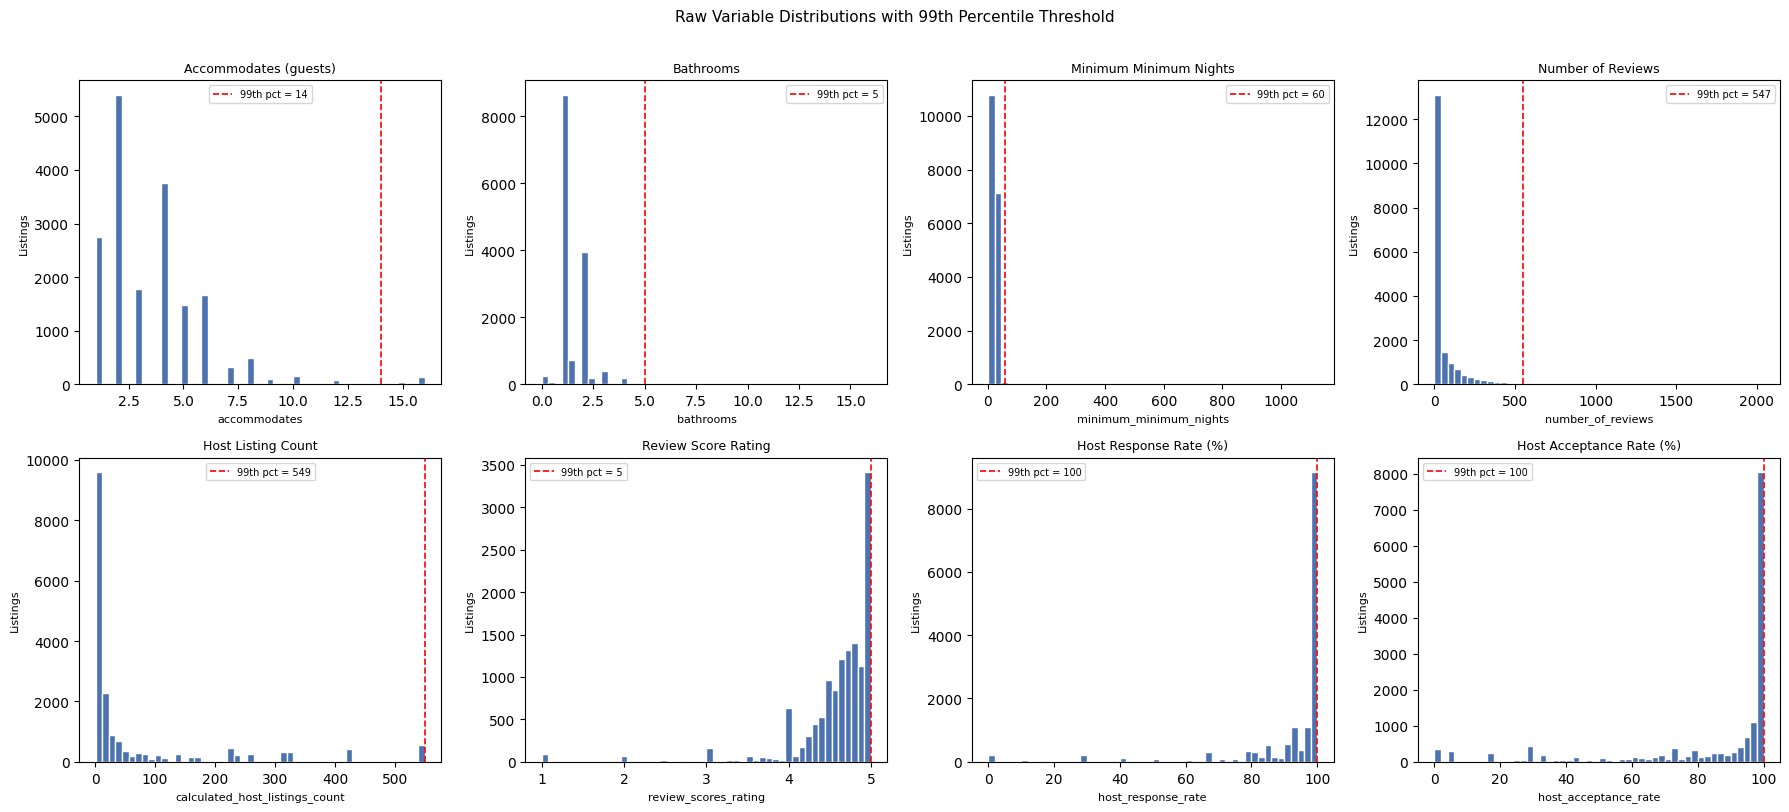

,column,1st pct,99th pct,max,n above 99th pct,pct of listings,n below 1st pct
0,accommodates,1.0,14.0,16.0,166,0.9%,0
1,bathrooms,0.0,5.0,16.0,117,0.6%,0
2,minimum_minimum_nights,1.0,60.0,1124.0,146,0.8%,0
3,number_of_reviews,0.0,547.0,2042.0,181,1.0%,0
4,calculated_host_listings_count,1.0,549.0,549.0,0,0.0%,0
5,review_scores_rating,2.0,5.0,5.0,0,0.0%,100
6,host_response_rate,0.0,100.0,100.0,0,0.0%,0
7,host_acceptance_rate,0.0,100.0,100.0,0,0.0%,0


In [ ]:
%matplotlib inline

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

# Variables evaluated for potential outliers prior to winsorization.
# Includes all continuous features used in Stage 2 scoring.
outlier_cols = [
    ("accommodates",                   "Accommodates (guests)"),
    ("bathrooms",                      "Bathrooms"),
    ("minimum_minimum_nights",         "Minimum Minimum Nights"),
    ("number_of_reviews",              "Number of Reviews"),
    ("calculated_host_listings_count", "Host Listing Count"),
    ("review_scores_rating",           "Review Score Rating"),
    ("host_response_rate",             "Host Response Rate (%)"),
    ("host_acceptance_rate",           "Host Acceptance Rate (%)"),
]

# host_response_rate and host_acceptance_rate are stored as strings ("100%")
# in the raw listings dataframe and must be converted to float before analysis.
pct_cols = {"host_response_rate", "host_acceptance_rate"}

for ax, (col, label) in zip(axes, outlier_cols):
    raw = listings[col].dropna()
    s = (raw.str.replace("%", "", regex=False).astype(float)
         if col in pct_cols else raw)
    ax.hist(s, bins=50, color="#4C72B0", edgecolor="white")
    p99 = s.quantile(0.99)
    ax.axvline(p99, color="red", linewidth=1.2, linestyle="--",
               label=f"99th pct = {p99:.0f}")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Listings", fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Raw Variable Distributions with 99th Percentile Threshold",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Summarize percentile thresholds and observations outside winsorization limits
rows = []
for col, label in outlier_cols:
    raw = listings[col].dropna()
    s = (raw.str.replace("%", "", regex=False).astype(float)
         if col in pct_cols else raw)
    p01, p99 = s.quantile(0.01), s.quantile(0.99)
    n_above = int((s > p99).sum())
    n_below = int((s < p01).sum())
    rows.append({
        "column": col,
        "1st pct": round(p01, 2),
        "99th pct": round(p99, 2),
        "max": round(s.max(), 2),
        "n above 99th pct": n_above,
        "pct of listings": f"{n_above/len(listings)*100:.1f}%",
        "n below 1st pct": n_below,
    })
pd.DataFrame(rows)


Extreme values are present in most columns but affect fewer than 1% of listings,
as shown in the summary table above. 
- `minimum_minimum_nights` has a maximum of 1,124 nights (effectively a long-term lease), far above its 99th percentile (shown by the
red dashed line in each panel). 
- `number_of_reviews` reaches 2,042 against a 99th percentile of 547.
- `calculated_host_listings_count` and `review_scores_rating` show zero observations above the 99th percentile: the first one
because the 99th percentile coincides with the maximum observed value (549), and the latter
because ratings are capped at 5.0 — meaning the 99th percentile coincides with the
maximum by construction.  
- For `review_scores_rating`, 100 listings fall below the 1st percentile (below 2.0):
these are listings with very low ratings that will be clipped upward by winsorization.
- `host_response_rate` and `host_acceptance_rate` are percentage values (0–100)
and show compact distributions with few extreme values.


In all cases, winsorizing at the 1st and 99th percentiles in Phase 4 handles outliers
without removing any rows.


#### 2.3.1.1 Correlation heatmap

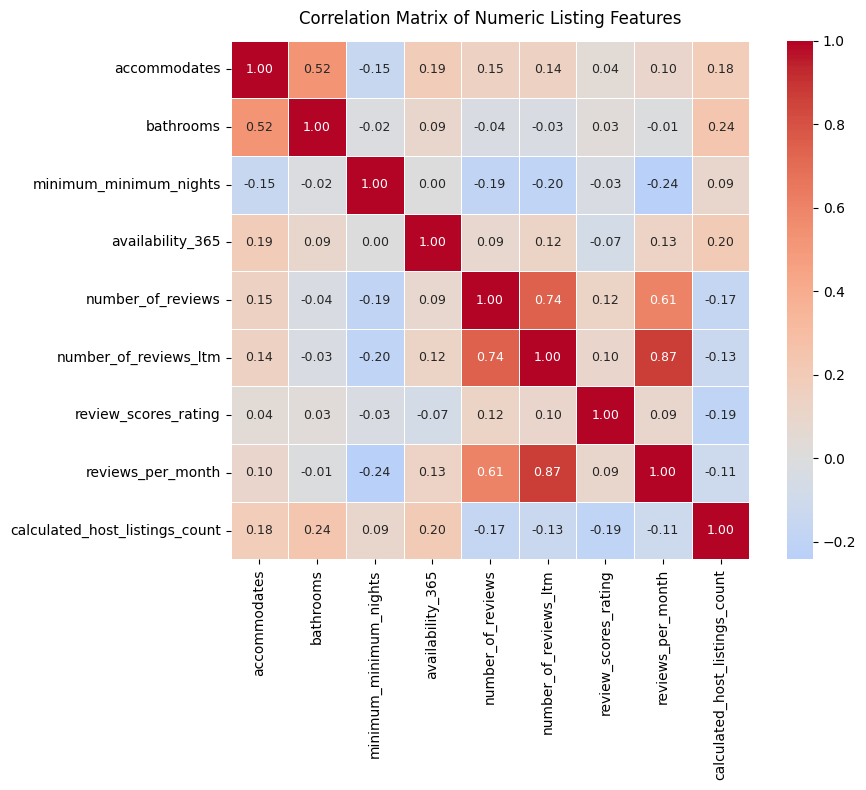

In [ ]:
# Numeric features included in the correlation analysis.
# The selection is based on the variables used by the recommendation model, 
# with number_of_reviews included additionally to assess potential redundancy with other review-related features.

heatmap_cols = [
    "accommodates", "bathrooms", "minimum_minimum_nights", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm", "review_scores_rating",
    "reviews_per_month", "calculated_host_listings_count",
]
heatmap_cols = [c for c in heatmap_cols
                if c in listings.columns and pd.api.types.is_numeric_dtype(listings[c])]

corr = listings[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax, annot_kws={"size": 9},
)
ax.set_title("Correlation Matrix of Numeric Listing Features", pad=12)
plt.tight_layout()
plt.show()


The strongest correlation is between `number_of_reviews_ltm` and `reviews_per_month`
(r = 0.87), confirming they capture nearly the same information. `number_of_reviews`
and `reviews_per_month` also show a moderate correlation (r = 0.61), and
`number_of_reviews` with `number_of_reviews_ltm` at r = 0.74. These three review
volume features share substantial signal. In the model, only `number_of_reviews_ltm`
is retained as the review activity feature; `reviews_per_month` is excluded (see
Phase 4.1) and `number_of_reviews` is kept in `listings_mdf` for reference only.

`accommodates` and `bathrooms` correlate at r = 0.52, reflecting that larger listings
tend to have more bathrooms, though not proportionally enough to treat bathroom count
as a pure capacity proxy. 

`review_scores_rating` and `calculated_host_listings_count`
show a weak negative relationship (r = -0.19): hosts operating at commercial scale
tend to receive slightly lower ratings on average. 

Most other pairs are near zero, indicating the selected features are largely independent.


#### 2.3.1.2 Distributions of key variables

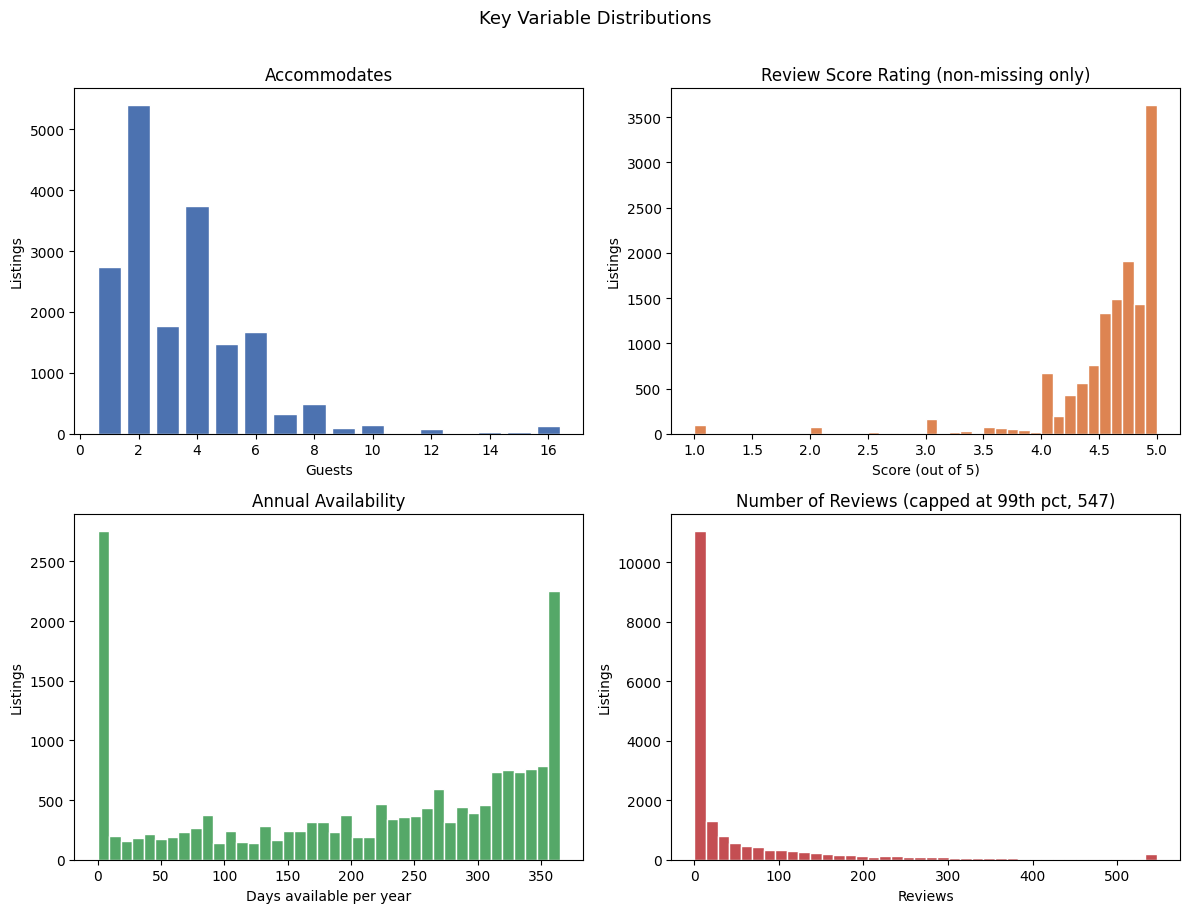

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Distribution of guest capacity across listings
ax = axes[0, 0]
vc = listings["accommodates"].value_counts().sort_index()
ax.bar(vc.index, vc.values, color="#4C72B0", edgecolor="white")
ax.set_title("Accommodates")
ax.set_xlabel("Guests")
ax.set_ylabel("Listings")

# Distribution of review ratings (excluding missing values)
ax = axes[0, 1]
ax.hist(listings["review_scores_rating"].dropna(), bins=40,
        color="#DD8452", edgecolor="white")
ax.set_title("Review Score Rating (non-missing only)")
ax.set_xlabel("Score (out of 5)")
ax.set_ylabel("Listings")

# Distribution of annual availability
ax = axes[1, 0]
ax.hist(listings["availability_365"], bins=40,
        color="#55A868", edgecolor="white")
ax.set_title("Annual Availability")
ax.set_xlabel("Days available per year")
ax.set_ylabel("Listings")

# Distribution of number of reviews
ax = axes[1, 1]
cap99 = listings["number_of_reviews"].quantile(0.99)
ax.hist(listings["number_of_reviews"].clip(upper=cap99), bins=40,
        color="#C44E52", edgecolor="white")
ax.set_title(f"Number of Reviews (capped at 99th pct, {int(cap99)})")
ax.set_xlabel("Reviews")
ax.set_ylabel("Listings")

fig.suptitle("Key Variable Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

- Most listings accommodate 2 or 4 guests, with a long tail up to 16. 
- Review scores are strongly left-skewed: the median is 4.72 out of 5, and scores below 4 are rare. This compression near the upper end of the scale means raw rating alone is a weak differentiator among good listings. 
- Availability shows a bimodal pattern with a cluster near 0 and a cluster near 365 (permanently available). This distribution motivates the `require_availability` filter in Stage 1, which excludes listings with `availability_365 == 0` from the candidate pool. 
- Review counts follow a highly right-skewed distribution even after capping at the 99th percentile.


#### 2.3.1.3 Room type and district breakdown

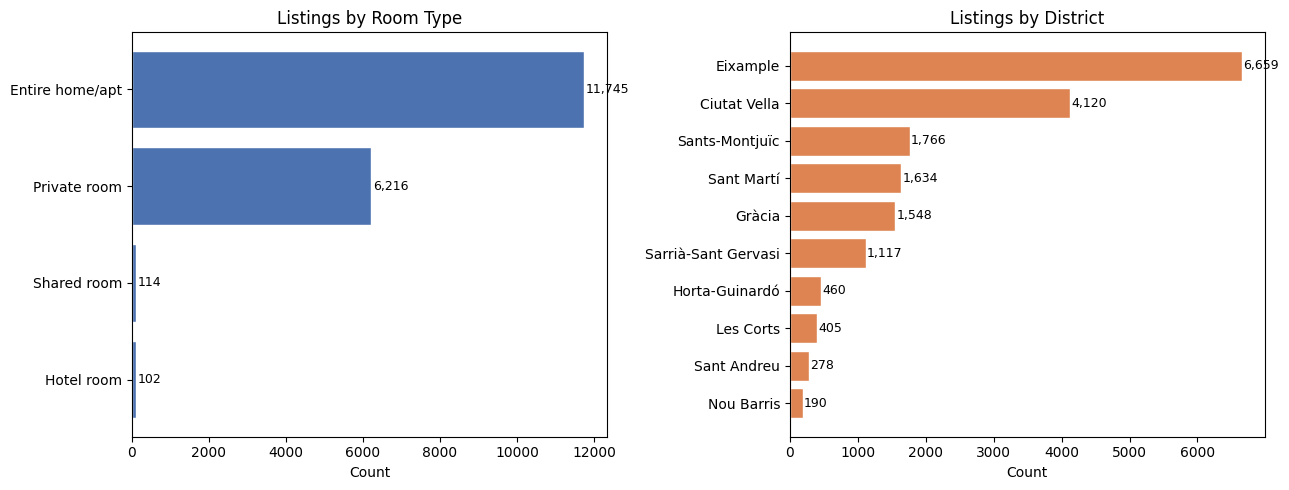

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution of listings by room type
ax = axes[0]
rt = listings["room_type"].value_counts()
bars = ax.barh(rt.index[::-1], rt.values[::-1], color="#4C72B0", edgecolor="white")
ax.set_title("Listings by Room Type")
ax.set_xlabel("Count")
for i, v in enumerate(rt.values[::-1]):
    ax.text(v + 40, i, f"{v:,}", va="center", fontsize=9) # Display exact counts next to each bar

# Distribution of listings across Barcelona districts
ax = axes[1]
dist = listings["neighbourhood_group_cleansed"].value_counts()
ax.barh(dist.index[::-1], dist.values[::-1], color="#DD8452", edgecolor="white")
ax.set_title("Listings by District")
ax.set_xlabel("Count")
for i, v in enumerate(dist.values[::-1]): 
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9) # Display exact counts next to each bar

plt.tight_layout()
plt.show()

- Entire homes and apartments account for 65% of listings (11,745), and private rooms
for 34% (6,216). Shared rooms and hotel rooms together represent under 1% and are a
niche category. 
- Geographically, Eixample dominates with 6,659 listings (37%), followed
by Ciutat Vella with 4,120 (23%). These two central districts together account for 60%
of total supply and are also the two districts with the highest crime incident counts
in the security dataset, which is relevant for Stage 2 context scoring.

### 2.3.2 Review data analysis

Review data is analysed separately from the listing-level variables: the review dataset is a different unit of analysis (each row is a single review, not a listing) so its volume and temporal patterns require their own exploration.

The analysis below examines volume trends over time and the language distribution of reviews, both of which have direct implications for the SBERT encoding step in Stage 3.

#### 2.3.2.1 Review volume over time

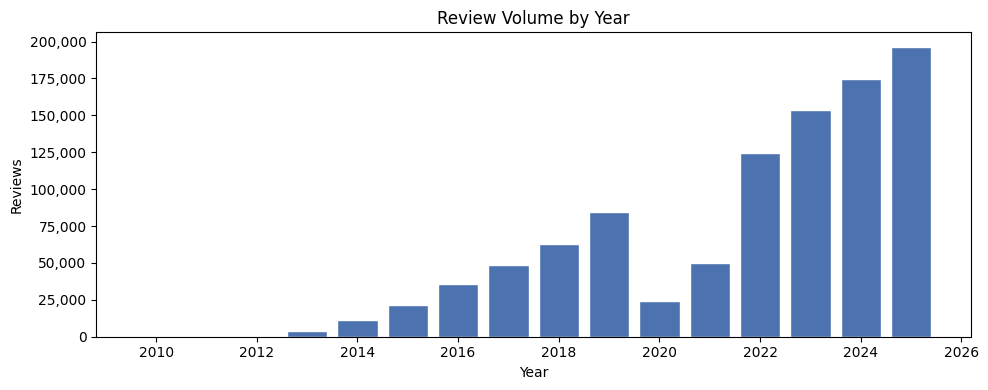

date
2019     84748
2020     24029
2021     50197
2022    124781
2023    153310
2024    174482
2025    196447


In [ ]:
reviews["date"] = pd.to_datetime(reviews["date"])
by_year = reviews.groupby(reviews["date"].dt.year).size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_year.index, by_year.values, color="#4C72B0", edgecolor="white")
ax.set_title("Review Volume by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
print(by_year.tail(7).to_string())

Review activity spans October 2010 to December 2025. The sharp contraction in 2020
(24,029 reviews, down from 84,748 in 2019) reflects the disruption to tourism from the
COVID-19 pandemic. Recovery accelerated through 2022 (124,781) and continued through
2024 (174,482), with 2025 already exceeding the pre-pandemic peak at 196,447.

Reviews are not filtered by date in Stage 3. A hard cutoff by year would disadvantage
low-turnover listings that receive reviews infrequently, many of which are precisely the
kind of locally-run, low-volume operations that may score highly on authenticity.

#### 2.3.2.2 Review language distribution

Language distribution in 2,000-review sample:
         pct (%)
en          60.5
es          11.3
fr          10.1
de           4.5
it           3.6
pt           1.9
ko           1.2
nl           0.9
zh-cn        0.8
unknown      0.8


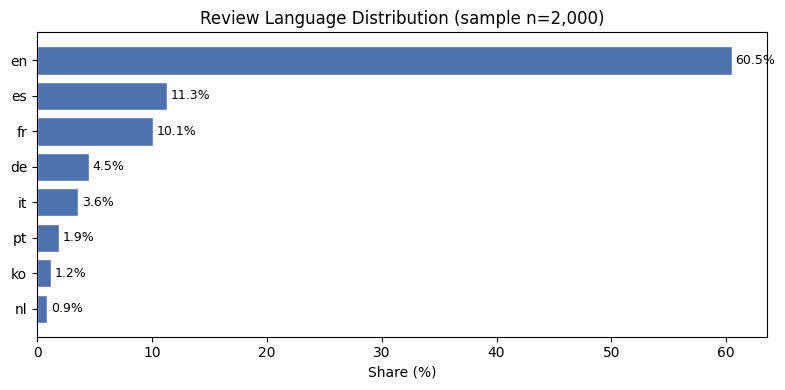

In [ ]:
# Draw a reproducible random sample to estimate the language distribution
sample_comments = (
    reviews["comments"]
    .dropna()
    .sample(2000, random_state=RANDOM_SEED)
    .tolist()
)

lang_counts = {}

# Detect the language of each review and count occurrences
for text in sample_comments:
    try:
        lang = detect(text)
    except LangDetectException:
        lang = "unknown"
    lang_counts[lang] = lang_counts.get(lang, 0) + 1

lang_series = (
    pd.Series(lang_counts)
    .sort_values(ascending=False)
)

# Convert counts to percentage shares
lang_pct = (lang_series / lang_series.sum() * 100).round(1)

print("Language distribution in 2,000-review sample:")
print(lang_pct.head(10).to_frame("pct (%)").to_string())

# Visualize the most common languages in the sample
fig, ax = plt.subplots(figsize=(8, 4))
top = lang_pct.head(8)
ax.barh(top.index[::-1], top.values[::-1], color="#4C72B0", edgecolor="white")
ax.set_xlabel("Share (%)")
ax.set_title("Review Language Distribution (sample n=2,000)")
for i, v in enumerate(top.values[::-1]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

A random sample of 2,000 reviews was analyzed using `langdetect`. English and Spanish
together account for the substantial majority of reviews (71.7%). This justifies two design
choices: 
- the SBERT model selected (`paraphrase-multilingual-mpnet-base-v2`, trained on
50+ languages) natively supports both, mapping semantically similar sentences from either
language to nearby positions in the same embedding space without any translation step.

- The boilerplate denylist in Stage 3 is also scoped to English and Spanish, as minor
languages present in the remaining share are individually too infrequent to warrant
dedicated filtering rules.

## 2.4 Data Quality

### 2.4.1 Missingness

#### Missingness in listings dataset

In [ ]:
missing = listings.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(1).rename("missing %").to_frame()

,missing %
neighbourhood,100.0
estimated_revenue_l365d,100.0
neighborhood_overview,100.0
price,100.0
calendar_updated,100.0
host_neighbourhood,53.9
license,39.4
host_about,36.1
review_scores_checkin,28.0
review_scores_value,28.0


Five columns are entirely empty (`neighborhood`, `neighborhood_overview`, `calendar_updated`,
`estimated_revenue_l365d`, and `price`). As mentioned in section 2.2.1, these columns are unpopulated in this dataset extract and are excluded from all processing.

Missingness in the modeling-relevant columns (`review_scores_rating`,
`host_response_rate`, `host_acceptance_rate`, `host_response_time`, `bathrooms_text`) is
addressed in Phase 4.2.2 with median imputation and binary flags to record which values
were imputed.

#### Missingness in supporting datasets

A brief missingness check is performed on all supporting datasets to identify structural
gaps before any processing. The code cell below prints columns with missing values for
`reviews`, `transport_stops_raw`, `income`, and `security`.


In [ ]:
# Missingness summary for each supporting dataset
for name, df in [
    ("reviews",   reviews),
    ("transport", transport_stops_raw),
    ("income",    income),
    ("security", security_raw)
]:
    missing = df.isna().mean() * 100
    missing = missing[missing > 0].round(1)
    if len(missing):
        print(f"\n{name} — columns with missing values:")
        print(missing.rename("missing %").to_frame().to_string())
    else:
        print(f"\n{name} — no missing values.")



reviews — columns with missing values:
               missing %
reviewer_name        0.0
comments             0.0

transport — columns with missing values:
                     missing %
stop_code                 26.4
stop_desc                 76.6
zone_id                  100.0
stop_url                  77.7
parent_station            95.7
stop_timezone             98.5
wheelchair_boarding        2.0

income — no missing values.

security — no missing values.


# Phase 4: Data Preparation

## 4.1 Select Data

Only columns with a clear modeling purpose are carried forward. 

**Note:** `id`, `latitude`,`longitude`, `neighbourhood_cleansed`, `neighbourhood_group_cleansed`, `room_type`, and `host_location` are not model features but are retained as join keys, filter inputs, or inputs to derived features.

In [ ]:
listings_relevant_columns = [
    "id", "host_response_time", "host_response_rate", "host_acceptance_rate", "host_is_superhost", "host_identity_verified", 
    "host_location", "neighbourhood_cleansed", "neighbourhood_group_cleansed", "latitude", "longitude", "room_type", "accommodates",
    "bathrooms_text", "minimum_minimum_nights", "maximum_maximum_nights","availability_365", "number_of_reviews", "number_of_reviews_ltm",
    "review_scores_rating", "calculated_host_listings_count"
]

listings_mdf = listings[listings_relevant_columns].copy()
print(f"listings_mdf: {listings_mdf.shape}")

listings_mdf: (18177, 21)


**Excluded from `listings_mdf`:**

- `bedrooms` and `beds` scale with `accommodates`, so they are a
capacity/configuration signal rather than an independent quality indicator.

- `instant_bookable` is excluded from scoring because the feature has no clear direction
in this context. It could reasonably be argued to indicate a more accessible and
professionally managed listing (positive signal), or an impersonal, automated operation
with no host interaction (negative signal). Including a feature with no defensible
directional choice would introduce an arbitrary weighting decision into the score.

- `host_verifications` is a string-encoded list requiring parsing for a binary signal
already covered more cleanly by `host_identity_verified`.

- The three `calculated_host_listings_count_*` sub-columns (entire homes, private rooms,
shared rooms) are removed. Only the total `calculated_host_listings_count` is used, in
Stage 3 structural authenticity scoring.

- `reviews_per_month` is excluded from the review quality subscore. It correlates with
`number_of_reviews_ltm` at r=0.87, indicating substantial overlap in the information they capture. 
Unlike `number_of_reviews_ltm`, which is a straightforward count of reviews received during the last 12 months, 
`reviews_per_month` is normalised by the listing's time on the platform. This makes the metric less stable 
for recently listed properties, where a short operating history can inflate or deflate the average. 
`number_of_reviews_ltm` provides a more interpretable and robust measure of recent review activity.

- The point-in-time `minimum_nights` and its smoothed annual average `minimum_nights_avg_ntm` are not used for filtering. **`minimum_minimum_nights`** is the stay-duration column used in Stage 1 filtering.
It represents the minimum stay this listing will accept at any point over the next 12
months, making it the most permissive and operationally correct choice: a listing that
accepts short stays seasonally should not be excluded because of a temporarily elevated
minimum set for peak periods. 


## 4.2 Clean Data

### 4.2.1 Type conversion and format standardisation

In [ ]:
# Percentages stored as strings: "95%" -> 0.95
listings_mdf["host_acceptance_rate"] = (
    listings["host_acceptance_rate"]
    .str.replace("%", "", regex=False).astype(float) / 100
)
listings_mdf["host_response_rate"] = (
    listings["host_response_rate"]
    .str.replace("%", "", regex=False).astype(float) / 100
)

# Convert boolean flags ("t"/"f") to numeric values.
# Float dtype is used so missing values remain NaN until imputation.
for col in ["host_is_superhost", "host_identity_verified"]:
    listings_mdf[col] = listings_mdf[col].map({"t": 1.0, "f": 0.0}).astype("float")

# host_response_time: text categories -> ordinal numeric
listings_mdf["host_response_time"] = listings_mdf["host_response_time"].map({
    "within an hour": 3, "within a few hours": 2,
    "within a day": 1,   "a few days or more": 0,
}).astype("float")

# Parse bathrooms_text into a numeric count and a shared/private flag.
# bathrooms_text has only 9 missing values vs 3,558 for the numeric bathrooms column, and preserves half-bath information 
# (e.g. "1.5 shared baths").
listings_mdf["bathrooms"] = listings_mdf["bathrooms_text"].apply(parse_bathrooms_text)
listings_mdf["bathroom_is_shared"] = listings_mdf["bathrooms_text"].apply(parse_bathroom_is_shared)
print("Parse failures:", listings_mdf["bathrooms"].isna().sum()
      - listings_mdf["bathrooms_text"].isna().sum())

listings_mdf[["bathrooms_text", "bathrooms", "bathroom_is_shared"]].drop_duplicates("bathrooms_text").sort_values("bathrooms").head(10)


Parse failures: 0


,bathrooms_text,bathrooms,bathroom_is_shared
192,0 baths,0.0,0.0
115,0 shared baths,0.0,1.0
948,Private half-bath,0.5,0.0
35,Shared half-bath,0.5,1.0
1045,Half-bath,0.5,0.0
1,1 bath,1.0,0.0
3,1 shared bath,1.0,1.0
6,1 private bath,1.0,0.0
76,1.5 shared baths,1.5,1.0
4,1.5 baths,1.5,0.0


### 4.2.2 Missing value handling

In [ ]:
# Missing value flags: indicator recording whether each value was originally present before imputation 
# These flags preserve information about structural missingness after imputation, allowing downstream analyses 
# to distinguish imputed values from observed ones.

listings_mdf["has_reviews"]            = listings_mdf["review_scores_rating"].notna().astype(int)
listings_mdf["has_host_response_data"] = listings_mdf["host_response_rate"].notna().astype(int)
listings_mdf["has_bathrooms_data"]     = listings_mdf["bathrooms"].notna().astype(int)

print(f"No reviews:            {(listings_mdf['has_reviews']==0).sum():,} "
      f"({(listings_mdf['has_reviews']==0).mean()*100:.1f}%)")
print(f"No host response data: {(listings_mdf['has_host_response_data']==0).sum():,} "
      f"({(listings_mdf['has_host_response_data']==0).mean()*100:.1f}%)")
print(f"No bathrooms data:     {(listings_mdf['has_bathrooms_data']==0).sum():,} "
      f"({(listings_mdf['has_bathrooms_data']==0).mean()*100:.1f}%)")

# Median imputation for columns with structural missingness.
for col in ["review_scores_rating", "number_of_reviews_ltm",
            "host_response_rate", "host_acceptance_rate",
            "host_response_time", "bathrooms"]:
    listings_mdf[col] = listings_mdf[col].fillna(listings_mdf[col].median())

# Conservative fill with 0 for binary trust signals.
for col in ["host_is_superhost", "host_identity_verified", "bathroom_is_shared"]:
    listings_mdf[col] = listings_mdf[col].fillna(0)

check_cols = ["review_scores_rating", "number_of_reviews_ltm",
              "host_response_rate", "host_acceptance_rate",
              "host_response_time", "bathrooms",
              "host_is_superhost", "host_identity_verified"]
remaining_nans = listings_mdf[check_cols].isna().sum().sum()
print(f"Remaining NaNs in score-relevant columns: {remaining_nans}")


No reviews:            5,082 (28.0%)
No host response data: 2,781 (15.3%)
No bathrooms data:     9 (0.0%)
Remaining NaNs in score-relevant columns: 0


Three missingness patterns are addressed, each handled differently depending on why the
data is missing:

- **Review columns** (`review_scores_rating`, `number_of_reviews_ltm`) are missing for
the 5,082 listings (28%) that have never received a review. The data does not exist for
these listings rather than being lost. They are imputed with the dataset median so they
remain in the candidate pool, and a `has_reviews` flag records which listings were
imputed. This avoids penalizing new or low-traffic listings purely for having no review
history.

- **Host responsiveness columns** (`host_response_rate`, `host_response_time`,
`host_acceptance_rate`) are missing for the 2,781 listings (15.3%) whose hosts have
never interacted with a booking request. Same approach: median imputation plus a
`has_host_response_data` flag.

- **Bathrooms** has 9 missing values after parsing from `bathrooms_text`. Imputed with
the median.

**`host_is_superhost` and `host_identity_verified`** have negligible missingness (0%
and 0.03% respectively). These are filled with 0, the conservative default: absence of
a superhost badge or a verified identity is not treated as evidence of the positive
label.


## 4.3 Construct Data

Before any scoring can happen, a few features need to be built that do not exist
directly in the raw data. A listing's quality depends not just on what the host says
about it, but on things like how close it is to a bus stop or a museum, how safe its district is, or  how many bathrooms it has relative to how many guests it accommodates. None of these are single columns in the dataset, so they need to be calculated.

This section constructs four features:

- **Bathrooms per guest**: how many bathrooms the listing provides for each guest it
  accommodates — a proxy for comfort that accounts for group size.
- **Transport proximity**: how many public transport stops are within 250 metres (default value), and
  the distance to the nearest one.
- **Points-of-interest proximity**: the same two metrics against Barcelona's cultural
  venues and civic centres.
- **District security**: the number of known criminal incidents in 2025 for the
  district the listing is located in.

All four features are used as raw inputs. They are normalised and combined into
subscores in Section 4.5.


### 4.3.1 Bathrooms per guest

Unlike bedrooms and beds, bathroom count does not increase proportionally with accommodates (1-4 guest listings all have a median of 1 bathroom; 5-6 guest listings have 1.5), making the ratio a useful cross-listing comparator.

**Bathrooms per guest** measures how many bathrooms a listing provides relative
to its stated capacity (`accommodates`). 

Examples:
- A listing with 2 bathrooms for 4 guests
scores 0.5
- one with 1 bathroom for 4 guests scores 0.25. 

The ratio uses `accommodates` (the listing's stated capacity) rather than the trip's guest count,
because the feature should reflect a property of the listing itself, not the
specific query.

The ratio is capped at 1.0 (one bathroom per guest). Beyond that point, additional
bathrooms do not meaningfully improve comfort — a 4-guest listing with 5 bathrooms
is not noticeably better than one with 4. The cap prevents surplus bathrooms from
inflating the score and keeps the feature interpretable: 1.0 means fully equipped,
anything below means bathrooms are shared to some degree.


In [ ]:
listings_mdf["bathrooms_per_guest"] = (
    listings_mdf["bathrooms"]
    / listings_mdf["accommodates"].replace(0, np.nan)
    # accommodates has no zero values in this dataset (minimum is 1),
    # so division never produces NaN. The replace(0, np.nan) guard is kept for safety.
).clip(upper=1.0) # See the markdown cell above for the rationale for capping at 1.0.
listings_mdf["bathrooms_per_guest"].describe()


count    18177.000000
mean         0.488647
std          0.272149
min          0.000000
25%          0.250000
50%          0.500000
75%          0.500000
max          1.000000
Name: bathrooms_per_guest, dtype: float64

### 4.3.2 Transport proximity

For each listing, two raw metrics are computed against the public transport stop
network: the distance in metres to the nearest stop, and the number of stops within
250 metres. A tighter radius of 250m is used for the density count rather than 500m
because Barcelona's GTFS network includes every individual bus stop, making counts at
500m too uniform across the city to be discriminating.

Both metrics use `haversine_chunked`, which processes listings in batches to avoid
building the full distance matrix (18,177 listings x 7,257 stops) in memory at once.

In [ ]:
# Retain only transport stops located within the approximate geographic
# boundaries of Barcelona. Latitude and longitude thresholds were derived
# from the city's extent as observed in Google Maps.

transport_stops_bcn = transport_stops_raw[
    transport_stops_raw["stop_lat"].between(41.30, 41.48) &
    transport_stops_raw["stop_lon"].between(2.04, 2.24) &
    transport_stops_raw["location_type"].isin([0, 1])
].copy()
print(f"Stops retained: {len(transport_stops_bcn):,} of {len(transport_stops_raw):,}")

nearest_stop_dist, stops_within_radius = haversine_chunked(
    listings_mdf["latitude"].values, listings_mdf["longitude"].values,
    transport_stops_bcn["stop_lat"].values, transport_stops_bcn["stop_lon"].values,
    radius_m=TRANSPORT_DENSITY_RADIUS_M,
)
listings_mdf["nearest_transport_stop_m"]    = nearest_stop_dist
listings_mdf["transport_stops_within_250m"] = stops_within_radius
listings_mdf[["nearest_transport_stop_m", "transport_stops_within_250m"]].describe()

Stops retained: 6,781 of 23,186


,nearest_transport_stop_m,transport_stops_within_250m
count,18177.000000,18177.000000
mean,91.552795,12.105188
std,50.683106,7.146107
min,0.462541,0.000000
25%,53.078438,7.000000
50%,85.212435,11.000000
75%,122.213518,15.000000
max,471.403254,57.000000


### 4.3.3 Points-of-interest proximity

The same two raw metrics are computed against Barcelona's points-of-interest dataset:
cultural venues and civic centres. A 500m walkable radius is used here since
the POI dataset (878 venues) is sparse enough that density at 500m still varies
meaningfully across the city.

In [ ]:
nearest_poi_dist, poi_within_radius = haversine_chunked(
    listings_mdf["latitude"].values, listings_mdf["longitude"].values,
    poi_raw["geo_epgs_4326_lat"].values, poi_raw["geo_epgs_4326_lon"].values,
    radius_m=PROXIMITY_RADIUS_M,
)
listings_mdf["nearest_poi_m"]   = nearest_poi_dist
listings_mdf["poi_within_500m"] = poi_within_radius
listings_mdf[["nearest_poi_m", "poi_within_500m"]].describe()

,nearest_poi_m,poi_within_500m
count,18177.000000,18177.000000
mean,154.092996,16.673488
std,110.751764,13.875161
min,0.413598,0.000000
25%,73.824187,6.000000
50%,127.964275,13.000000
75%,207.703968,24.000000
max,1152.983165,75.000000


### 4.3.4 District security

Known criminal incident counts for 2025 are retrieved at district level. The raw
count is kept as-is here; inversion (fewer incidents = higher score) happens during
normalisation in Section 4.5. Data is sourced from the Mossos d'Esquadra (Catalan
Police) published statistics, which report at district granularity only.

In [ ]:
security_districts = security_raw[
    (security_raw["Tipus de territori"] == "Districte") &
    (security_raw["Territori"] != "Districte no informat")
].copy()

# Values use "." as a thousands separator: "8.798" = 8,798 incidents
security_districts["incidents_2025"] = (
    security_districts["2025"].str.replace(".", "", regex=False).astype(int)
)

city_total = int(
    security_raw.loc[security_raw["Territori"] == "Barcelona", "2025"]
    .iloc[0].replace(".", "")
)
district_sum = security_districts["incidents_2025"].sum()
# Data integrity check: district incident counts should sum close to the city total.
# The small remainder represents incidents reported as district-unknown in the source data.
# If the gap is large, it would indicate a parsing error or missing districts.
print(f"District total: {district_sum:,}  |  City total: {city_total:,}  "
      f"|  Unreported district: {city_total - district_sum:,}")

districts_match = set(listings["neighbourhood_group_cleansed"].dropna().unique()) == set(
    security_districts["Territori"]
)
print(f"District names align between listings and security data: {districts_match}")

District total: 167,615  |  City total: 169,082  |  Unreported district: 1,467
District names align between listings and security data: True


Security data is available at district granularity only (10 districts). Every listing
within a district therefore receives the same security value.

## 4.4 Integrate Data

In [ ]:
listings_mdf = listings_mdf.merge(
    security_districts[["Territori", "incidents_2025"]],
    left_on="neighbourhood_group_cleansed", right_on="Territori", how="left",
).drop(columns=["Territori"])

missing_security = listings_mdf["incidents_2025"].isna().sum()
print(f"Security data integrated, {missing_security} missing.")

Security data integrated, 0 missing.


## 4.5 Normalise Features and Compute Subscores


Every raw feature constructed in Section 4.3 is normalised here using
`winsorize_normalize` (clipped at the 1st and 99th percentile, then scaled to [0, 1]),
and combined into the subscores for Stage 2.

### 4.5.1 Host quality subscore


In [ ]:
host_quality_cols = [
    "host_response_rate", "host_acceptance_rate", "host_is_superhost",
    "host_response_time", "host_identity_verified", "bathrooms_per_guest",
]

for col in host_quality_cols:
    listings_mdf[col + "_norm"] = winsorize_normalize(listings_mdf[col])

listings_mdf["host_quality_subscore"] = (
    listings_mdf[[c + "_norm" for c in host_quality_cols]].mean(axis=1)
    # Equal weights within host_quality_subscore: all six features capture
    # independent dimensions of hosting quality with no single dominant signal.
)

listings_mdf[["host_quality_subscore"]].describe()

,host_quality_subscore
count,18177.000000
mean,0.718518
std,0.132920
min,0.200000
25%,0.663333
50%,0.720556
75%,0.828333
max,1.000000


### 4.5.2 Review quality subscore


In [ ]:
review_quality_cols = [
    "review_scores_rating",
    "number_of_reviews_ltm",
]

for col in review_quality_cols:
    listings_mdf[col + "_norm"] = winsorize_normalize(listings_mdf[col])


REVIEW_WEIGHTS = {
    "review_scores_rating_norm":  0.70,
        # the direct quality measure, the actual outcome guests report.
    "number_of_reviews_ltm_norm": 0.30,
        # review activity in the last 12 months,a volume signal rather than a quality signal
        # so weighted as secondary.
}

listings_mdf["review_quality_subscore"] = sum(
    w * listings_mdf[col] for col, w in REVIEW_WEIGHTS.items()
)

listings_mdf[["review_quality_subscore"]].describe()

,review_quality_subscore
count,18177.000000
mean,0.636827
std,0.130395
min,0.000000
25%,0.621600
50%,0.621600
75%,0.703571
max,0.991600


### 4.5.2 Context subscore

For transport and POI, two components are combined into one subfeature each. 
- The distance component (closer is better) is inverted before normalising so the resulting
score follows the convention that higher means better. 
- The density component (more stops or POIs within radius is better) is normalised in the standard direction. The two components are averaged into a single subfeature per domain.

For security, the raw incident count is inverted so fewer incidents produce a higher
score. 

The three subfeatures are then averaged into `context_subscore`.

In [ ]:
listings_mdf["transport_subfeature"] = (
    winsorize_normalize(listings_mdf["nearest_transport_stop_m"], invert=True) +
    winsorize_normalize(listings_mdf["transport_stops_within_250m"])
) / 2

listings_mdf["poi_subfeature"] = (
    winsorize_normalize(listings_mdf["nearest_poi_m"], invert=True) +
    winsorize_normalize(listings_mdf["poi_within_500m"])
) / 2

listings_mdf["security_subfeature"] = winsorize_normalize(
    listings_mdf["incidents_2025"], invert=True
)

listings_mdf["context_subscore"] = (
    listings_mdf["transport_subfeature"] +
    listings_mdf["poi_subfeature"] +
    listings_mdf["security_subfeature"]
) / 3

print(f"Final listings_mdf shape: {listings_mdf.shape}")
listings_mdf["context_subscore"].describe()

Final listings_mdf shape: (18177, 46)


count    18177.000000
mean         0.431316
std          0.152605
min          0.075638
25%          0.324043
50%          0.400417
75%          0.528064
max          0.894469
Name: context_subscore, dtype: float64

# Phase 5: Modeling

This section implements the three-stage ranking pipeline that forms the core
contribution of this project. Each stage builds on the previous one: Stage 1 defines
the eligible candidate pool, Stage 2 ranks it by quality, and Stage 3 re-ranks the
top candidates by authenticity.

Three-stage architecture:

**Stage 1: Pre-Filtering**: deterministic hard constraints reduce the candidate pool to
listings that are operationally feasible for a given trip request.

**Stage 2: Base Ranking**: a transparent, manually defined weighted score selects the
Top-K candidate set based on general quality and contextual fit.

**Stage 3: Authenticity Re-Ranking**: combines Sentence-BERT (SBERT) semantic prototype
matching on guest reviews with structural host-level signals to re-rank the Top-K
by localness and authenticity.


## 5.1 Stage 1: Pre-Filtering

Hard constraints applied as a deterministic filter before any scoring. All conditions
must be satisfied simultaneously for a listing to proceed. The function `filter_listings`
is defined in Section 1.2. The trip profile parameters (`TRIP_GUESTS`, `TRIP_ROOM_TYPE`,
`TRIP_NIGHTS`) are defined in Section 0 and can be changed there to simulate a different
user query.

| Constraint | Column | Why this constraint |
|---|---|---|
| Capacity | `accommodates` | Excludes listings that cannot physically host the requested number of guests. |
| Room type | `room_type` | Ensures the listing type matches the user's preference (e.g. entire home vs private room). |
| Stay duration (min) | `minimum_minimum_nights` | Excludes listings whose minimum stay requirement exceeds the planned trip length. |
| Stay duration (max) | `maximum_maximum_nights` clipped at `MAX_STAY_CAP` | Excludes long-term rental listings that never allow stays as short as the trip; the cap at 90 nights removes permanent rentals from the candidate pool. |
| Availability | `availability_365` | Excludes inactive listings with zero availability days in the next 12 months, which are unlikely to accept bookings. |


In [ ]:
listings_filtered = filter_listings(
    listings_mdf,
    min_accommodates=TRIP_GUESTS,
    room_types=[TRIP_ROOM_TYPE] if TRIP_ROOM_TYPE else None,
    trip_nights=TRIP_NIGHTS,
    require_availability=True,
)
print(f"Trip profile: {TRIP_GUESTS} guests, {TRIP_ROOM_TYPE}, {TRIP_NIGHTS} nights")
print(f"Before filtering: {len(listings_mdf):,}")
print(f"After filtering:  {len(listings_filtered):,}")
print(f"Retention rate:   {len(listings_filtered)/len(listings_mdf)*100:.1f}%")


Trip profile: 2 guests, Entire home/apt, 4 nights
Before filtering: 18,177
After filtering:  6,484
Retention rate:   35.7%


## 5.2 Stage 2: Base Ranking

A transparent composite score is built from three subscores. Base scores are computed
on the trip-eligible pool of listings (`listings_filtered`) so that scoring reflects the actual
candidate set for a given query. 

> *For deployment purposes, stage 1 scores are additionally computed on the full pool (`listings_mdf`) so the app can re-run Stage 1 filtering dynamically without re-scoring. This means scores are a property of the listing
independent of any specific query, while eligibility is determined by the trip profile.

Weights were chosen to reflect the relative reliability of each signal given the
absence of interaction data. 

**`Base_score` component weights** (host 0.30 / review 0.40 / context 0.30): review
quality receives the most weight because it is the closest available proxy for overall
guest experience. Host quality and context are weighted equally because neither is more
informative than the other without interaction data to compare them against.

- **`host_quality_subscore` (0.30)**: equal weights across the six features (response rate,
acceptance rate, superhost status, response time, identity verified, bathrooms per
guest). Each captures an independent dimension of hosting reliability and no single
feature is dominant.

- **`review_quality_subscore` (0.40)**: 0.70 for rating, 0.30 for number_of_reviews_ltm. The
rating is the actual outcome guests report after their stay and is the strongest direct
quality signal available. `number_of_reviews_ltm` measures recent review activity, not
quality: a listing can accumulate many recent reviews simply through high turnover,
which is not the same as being a better stay. Weighting it at 0.30 keeps it as a
secondary signal rather than treating volume and rating as equally informative.
`reviews_per_month` was excluded entirely due to high redundancy with
`number_of_reviews_ltm` (r = 0.87).

- **`context_subscore`(0.30)**: equal weights across transport, POI, and security subfeatures.
These capture different spatial dimensions (accessibility, cultural richness, safety)
with no basis for prioritising one over the others.

Note: Neighbourhood income is intentionally excluded from `context_subscore`. Using
income as a ranking signal would risk associating higher-income areas with better
listings. Income is instead kept as a diagnostic variable to assess whether the
final ranking inadvertently correlates with socioeconomic status (see section 6.3).

The sensitivity analysis in Phase 6 tests whether the base ranking is robust to
alternative weight configurations.

In [ ]:
#weight configurations for the sensitivity analysis in Phase 6
WEIGHT_CONFIGS = {
    "default":       {"host": 0.30, "review": 0.40, "context": 0.30},
    "review_heavy":  {"host": 0.20, "review": 0.50, "context": 0.30},
    "context_heavy": {"host": 0.25, "review": 0.25, "context": 0.50},
}

def compute_base_score(df, weights):
    return (weights["host"]    * df["host_quality_subscore"] +
            weights["review"]  * df["review_quality_subscore"] +
            weights["context"] * df["context_subscore"])

# Compute on the full pool ("listings_mdf") so all listings carry a base score for the app export.
for name, w in WEIGHT_CONFIGS.items():
    weight_sum = sum(w.values())
    print(f"{name}: weights sum to {weight_sum:.3f}")
    listings_mdf[f"base_score_{name}"]      = compute_base_score(listings_mdf, w)
    # The pipeline (Top-K selection and sensitivity analysis) uses listings_filtered
    listings_filtered[f"base_score_{name}"] = compute_base_score(listings_filtered, w)

listings_filtered[["base_score_default",
                    "base_score_review_heavy",
                    "base_score_context_heavy"]].describe()


default: weights sum to 1.000
review_heavy: weights sum to 1.000
context_heavy: weights sum to 1.000


,base_score_default,base_score_review_heavy,base_score_context_heavy
count,6484.000000,6484.000000,6484.000000
mean,0.623940,0.617244,0.568394
std,0.086282,0.089107,0.094121
min,0.233619,0.186341,0.249986
25%,0.564610,0.557709,0.502202
50%,0.622754,0.616646,0.562036
75%,0.683404,0.677309,0.628403
max,0.898407,0.905754,0.884512


### 5.2.1 Select Top-K candidates for Stage 3

The Top-K listings are selected from `listings_filtered` by `base_score_default`.
Only these K listings proceed to Stage 3; the base score is not recomputed here,
it was already assigned in the cell above.


In [ ]:
# Top-K selection uses the filtered pool so only trip-eligible listings compete.
top_k_candidates = listings_filtered.nlargest(TOP_K, "base_score_default").copy()
top_k_candidates[["id", "neighbourhood_cleansed", "host_quality_subscore",
                   "review_quality_subscore", "context_subscore",
                   "base_score_default"]].head(10)


,id,neighbourhood_cleansed,host_quality_subscore,review_quality_subscore,context_subscore,base_score_default
5386,35488866,la Vila de Gràcia,0.873333,0.946800,0.858958,0.898407
12450,1110775765657684157,el Putxet i el Farró,0.866667,0.972000,0.788910,0.885473
5198,34191394,la Vila de Gràcia,0.887222,0.927200,0.813061,0.880965
3250,19028982,la Vila de Gràcia,0.889167,0.977600,0.742882,0.880655
6489,43235590,la Vila de Gràcia,0.903333,0.913200,0.805649,0.877975
11649,1025981229888939036,el Putxet i el Farró,0.900000,0.974800,0.725648,0.877614
11551,1019340307296601080,la Vila de Gràcia,0.916667,0.977600,0.697038,0.875152
5155,33816957,la Vila de Gràcia,0.875000,0.938400,0.785240,0.873432
3456,20066721,la Vila de Gràcia,0.900741,0.946714,0.742882,0.871772
7289,49963630,la Vila de Gràcia,0.916667,0.869400,0.827110,0.870893


## 5.3 Stage 3: Authenticity Re-Ranking

Stage 3 operates only on the top K listings already selected by `base_score_default` in
Stage 2. The base ranking score of stage 2 is used twice in this stage: 
- first to decide which listings reach Stage 3 (Top K, which is 100 by default), 
- and second as a continuing input alongside the authenticity score when the final ranking is produced.

The process has three steps. 
- First, an `authenticity_score` is computed for each of the 100 candidates by combining two independent signals: a SBERT text score (weight 0.50) and a host authenticity subscore (weight 0.50). 
- Second, a `final_score` is computed for each listing as a weighted combination of `base_score_default` (weight 0.70) and `authenticity_score` (weight 0.30): the validated Stage 2 signal continues to drive the
ranking, while authenticity differentiates among listings that are already similar in
quality. 
- Third, the 100 listings are sorted by `final_score` to produce `final_ranking`, which is the system output.

Regarding the `authenticity_score` subscores:
- **SBERT text score**: each review is encoded individually and scored by its contrast
similarity to a positive authenticity prototype minus a negative (commercial/impersonal)
prototype. The top-3 scoring reviews per listing are averaged to produce the listing-level
text score. This avoids diluting the authentic signal across many generic reviews while
being more robust than taking only the single best review.

- **Host authenticity subscore**: two host-level signals tied to localness:
`auth_host_scale` penalises large commercial multi-listing operators via
`1/log(1 + n_listings)`, and `auth_host_resident`prioritizes hosts that are more likely to be in the city (they set their location to Barcelona).


### 5.3.1 Authenticity prototype seeds

Seeds define the two poles of the authenticity dimension. They are written by hand
rather than sampled from the review corpus to avoid circularity (selecting from the
same dataset being scored may risk encoding stylistic biases from the
selection process rather than the underlying concept).

The model (`paraphrase-multilingual-mpnet-base-v2`) maps semantically similar
sentences from different languages to nearby positions in the same
embedding space, so translation is not required. However, if all seeds
were in English, the prototype vectors would be averages of English-only
embeddings, which may be slightly offset from the Spanish cluster in the
shared space. Spanish seeds are included to attempt to pull the prototypes toward the
centre of both language clusters, making them more language-neutral and
reducing the risk of systematically underscoring Spanish-language reviews
relative to English ones.


In [ ]:
POSITIVE_SEEDS = [
    # Host presence and personal touch (English)
    "The host lived nearby and gave us handwritten tips about the local market and their favorite cafes",
    "We almost felt like real residents, not tourists. Our host knew all the neighbors by name.",
    "The host left us a personal note with recommendations for places only locals know about.",
    "It felt like staying with a friend who actually lives in the city, not a rental managed remotely.",
    "Nothing corporate about it. Just a normal person renting their real apartment.",
    "The host was genuinely helpful. They actually cared and it was clear they were from here.",

    # Neighborhood feel, non-touristy (English)
    "The apartment is in a real working-class neighborhood, far from the tourist crowds.",
    "Woke up to the sounds of the local market downstairs. Felt completely immersed in everyday Barcelona life.",
    "The street was full of locals going about their day. No souvenir shops, no tour buses.",
    "A quiet residential street with a neighborhood bakery, a pharmacy, and families.",
    "You really experience what it is like to live in Barcelona, not just visit it.",
    "One feels like you are in a real neighbourhood, not a tourist zone.",

    # Host presence and personal touch (Spanish)
    "El anfitrion nos recibio personalmente y nos presento el barrio como si fuera su casa.",
    "El piso tiene alma, se nota que lo cuida una persona que vive en el barrio.",
    "El anfitrion vive en el mismo edificio y siempre estuvo disponible para cualquier cosa.",
    "Nos dejo una nota con recomendaciones de sitios que solo conocen los de aqui.",

    # Neighborhood feel, non-touristy (Spanish)
    "El barrio es autentico, con comercios de toda la vida y vecinos de siempre.",
    "Vivimos como barceloneses durante una semana, sin cruzarnos con otros turistas en la zona",
    "Una calle tranquila, lejos del ruido y las aglomeraciones, con panaderia, farmacia y vida de barrio.",
    "No se siente como un piso turistico. Es una casa de verdad en un barrio local de toda la vida.",
]

NEGATIVE_SEEDS = [
    # Commercial operation signals (English)
        # Target how the property is operated, based on host relationship and service structure
    "The apartment is managed by a professional team available 24/7 for any requests.",
    "Fully equipped for short stays, with hotel-like amenities and services included.",
    "The check-in was fully automated. A keypad code, no host interaction needed.",
    "Part of a professionally managed portfolio of apartments across the city center.",
    "The staff were super nice and very professional throughout our stay.",
    "The management team responded quickly and resolved everything efficiently.",
    "Check-in was fully automated with a lockbox code. We never met the host.",
    "A well-run property managed by a professional team. Everything was perfectly organised.",
    "The team managing the apartment made sure our stay was seamless from start to finish.",

    # Commercial operation signals (Spanish)
    "El edificio tiene varios apartamentos de Airbnb, todo muy organizado y profesional.",
    "El equipo de gestion fue muy eficiente y respondio rapidamente a todos nuestros mensajes.",
    "El proceso de entrada y salida fue totalmente automatico, sin contacto con el anfitrion.",
    "El personal del apartamento fue muy amable y profesional en todo momento.",
]

print(f"Positive seeds: {len(POSITIVE_SEEDS)}")
print(f"Negative seeds: {len(NEGATIVE_SEEDS)}")


Positive seeds: 20
Negative seeds: 13


### 5.3.2 Review text preprocessing

Before reviews can be encoded by SBERT, two filtering steps remove content that
would add noise rather than signal to the authenticity score.

- **Step 1 — Length filter**: reviews under 20 words are excluded. Very short reviews
contain too little content to produce a meaningful embedding.

- **Step 2 — Boilerplate denylist**: reviews that both (a) contain a generic phrase
from the denylist AND (b) are under 30 words are excluded. Therefore, only short reviews whose entire content is a generic template are removed. Phrases were identified by manually inspecting short reviews in both English and Spanish.

After filtering, up to 10 qualifying reviews per listing are retained (longest
first), kept as individual passages rather than concatenated, so each can be
scored independently in Section 5.3.4.


In [ ]:
BOILERPLATE_DENYLIST = [
    # English
    "great place to stay",
    "a great location",
    "very clean",
    "enjoyed our stay",
    "would definitely stay",
    "a great stay",
    "a great host",
    "clean and comfortable",
    "exactly as described",
    "will definitely come back",
    "highly recommend",
    "perfect location would recommend",
    "great host would recommend",
    # Spanish
    "muy bien ubicado",
    "muy recomendable",
    "todo perfecto",
    "anfitrión muy amable",
    "apartamento limpio y cómodo",
    "muy buena ubicación",
]
print(f"Denylist has {len(BOILERPLATE_DENYLIST)} phrases "
      f"(applied only to reviews under 30 words).")


Denylist has 19 phrases (applied only to reviews under 30 words).


The preprocessed reviews are assembled by reading `reviews.csv` in 50,000-row
chunks rather than loading the full 308 MB file at once. For each chunk, reviews
passing both filters are grouped by listing ID. Reviews are kept as individual
strings rather than joined, preserving the per-review granularity needed for the
top-3 mean aggregation in Section 5.3.4.


In [ ]:
# For each listing, keeps up to 10 individual reviews that pass the length and denylist filters
listing_review_lists = preprocess_reviews_chunked(
    DATA_DIR / "reviews.csv",
    chunk_size=50_000,
    min_words=20,
    max_reviews_per_listing=10,
    denylist=BOILERPLATE_DENYLIST,
)
print(f"Listings with qualifying review text: {len(listing_review_lists):,}")

Listings with qualifying review text: 12,196


### 5.3.3 SBERT encoding

Each qualifying review is encoded into an embedding vector using `paraphrase-multilingual-mpnet-base-v2`, a Sentence-BERT model that supports 50+ languages and maps semantically similar sentences across languages to nearby
positions in the same embedding space.

Encoding is applied at the **individual review level**. Each of the up to 10
filtered reviews per listing gets its own embedding vector. The model is loaded
once and applied to all reviews in a single batch for efficiency.

In [ ]:
SBERT_MODEL = "paraphrase-multilingual-mpnet-base-v2"
model = SentenceTransformer(SBERT_MODEL)
print(f"Model loaded: {SBERT_MODEL}")

# Encode all seeds and compute prototype vectors.
# The prototype is the mean embedding of all seed sentences of each type.
positive_embeddings = model.encode(POSITIVE_SEEDS, convert_to_numpy=True,
                                    show_progress_bar=False)
negative_embeddings = model.encode(NEGATIVE_SEEDS, convert_to_numpy=True,
                                    show_progress_bar=False)

positive_prototype = positive_embeddings.mean(axis=0)
negative_prototype = negative_embeddings.mean(axis=0)

print(f"Prototype vector shape: {positive_prototype.shape}")
print(f"Positive seeds encoded: {len(positive_embeddings)}")
print(f"Negative seeds encoded: {len(negative_embeddings)}")

# Flatten every individual review across the Top-100 candidates into one list,
# keeping track of which listing each review belongs to.
top100_ids_ordered = top_k_candidates["id"].tolist()

review_texts_flat = []
review_listing_ids = []
for lid in top100_ids_ordered:
    for review_text in listing_review_lists.get(lid, []):
        review_texts_flat.append(review_text)
        review_listing_ids.append(lid)

n_listings_with_reviews = len(set(review_listing_ids))
print(f"Encoding {len(review_texts_flat)} individual reviews across {n_listings_with_reviews} of {len(top100_ids_ordered)} candidates...")

review_embeddings = model.encode(
    review_texts_flat,
    convert_to_numpy=True,
    show_progress_bar=False,
    batch_size=32,
)
print(f"Review embeddings shape: {review_embeddings.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded: paraphrase-multilingual-mpnet-base-v2
Prototype vector shape: (768,)
Positive seeds encoded: 20
Negative seeds encoded: 13
Encoding 1000 individual reviews across 100 of 100 candidates...
Review embeddings shape: (1000, 768)


### 5.3.4 SBERT authenticity text score

Each review is scored individually against the positive and negative prototypes. Scores
are then aggregated per listing using the mean of the top-3 highest-scoring reviews.
This is more robust than taking the single maximum score (which is sensitive to one
unusually worded review) while being more discriminating than a plain mean across all
reviews (which dilutes the authentic signal inside many generic ones). The plain mean
across all reviews is also computed as a secondary diagnostic column.


In [ ]:
# Contrast score per individual review
sim_positive = cosine_sim_to_vector(review_embeddings, positive_prototype)
sim_negative = cosine_sim_to_vector(review_embeddings, negative_prototype)
review_contrast_scores = sim_positive - sim_negative

review_scores_df = pd.DataFrame({
    "id": review_listing_ids,
    "contrast_score": review_contrast_scores,
})

# Aggregate per listing using the mean of the top-3 scoring reviews.
def top3_mean(scores):
    return scores.nlargest(min(3, len(scores))).mean()

listing_agg = (
    review_scores_df
    .groupby("id")["contrast_score"]
    .agg(top3_mean=top3_mean, mean_all=("mean"))
)
listing_agg.columns = ["sbert_text_score_raw", "sbert_text_score_mean_raw"]
listing_agg = listing_agg.reset_index()

top_k_candidates = top_k_candidates.merge(listing_agg, on="id", how="left")

top_k_candidates["sbert_text_score_raw"]      = top_k_candidates["sbert_text_score_raw"].fillna(0)
top_k_candidates["sbert_text_score_mean_raw"] = top_k_candidates["sbert_text_score_mean_raw"].fillna(0)

top_k_candidates["sbert_text_score"] = winsorize_normalize(
    top_k_candidates["sbert_text_score_raw"]
)
top_k_candidates["sbert_text_score_mean"] = winsorize_normalize(
    top_k_candidates["sbert_text_score_mean_raw"]
)

print("SBERT text score distribution (top-3 mean, primary):")
print(top_k_candidates["sbert_text_score"].describe().round(3))
print("\nSBERT text score distribution (all-reviews mean, diagnostic):")
print(top_k_candidates["sbert_text_score_mean"].describe().round(3))
print(f"\nReviews scored: {len(review_contrast_scores)}")
print(f"Similarity to positive prototype: mean={sim_positive.mean():.3f}, std={sim_positive.std():.3f}")
print(f"Similarity to negative prototype: mean={sim_negative.mean():.3f}, std={sim_negative.std():.3f}")


SBERT text score distribution (top-3 mean, primary):
count    100.000
mean       0.537
std        0.228
min        0.000
25%        0.366
50%        0.537
75%        0.717
max        1.000
Name: sbert_text_score, dtype: float64

SBERT text score distribution (all-reviews mean, diagnostic):
count    100.000
mean       0.533
std        0.230
min        0.000
25%        0.378
50%        0.537
75%        0.726
max        1.000
Name: sbert_text_score_mean, dtype: float64

Reviews scored: 1000
Similarity to positive prototype: mean=0.505, std=0.081
Similarity to negative prototype: mean=0.399, std=0.083


### 5.3.5 Host authenticity subscore

The host authenticity subscore combines two structural signals:

**Signal 1 — `auth_host_scale` = 1 / log(1 + n_listings)**

- Penalises large commercial multi-listing operators. The logarithmic formula is
deliberate: the difference between 1 and 2 listings is far more meaningful than
the difference between 50 and 51. `log1p` (= log(1 + x)) avoids division by zero
for single-listing hosts where log(1) = 0.

**Signal 2 — `auth_host_resident`**

- Uses the host's stated location to flag whether they list a Barcelona address.
This is a proxy for local residency: 1.0 if the host location contains "Barcelona",
0.5 if unknown or missing, 0.0 if clearly elsewhere.

- *Known limitation*: this field is self-reported and unverified. A remote operator
could list "Barcelona, Spain" without being locally embedded. 

**Combined subscore (weighted mean):**

- host_authenticity_subscore = 0.70 × auth_host_scale_norm + 0.30 × auth_host_resident_norm

In [ ]:
# auth_host_scale: penalises large commercial multi-listing operators.
#   - Single-listing host scores 1/log(2) ≈ 1.44 (normalised to near 1.0)
#   - Host with 5 listings scores 1/log(6) ≈ 0.56
#   - Very large operators (50+ listings) approach 0
listings_mdf["auth_host_scale"] = 1 / np.log1p(
    listings_mdf["calculated_host_listings_count"]
)
listings_mdf["auth_host_scale_norm"] = winsorize_normalize(listings_mdf["auth_host_scale"])

# auth_host_resident: proxy for local residency via host's stated location.
listings_mdf["auth_host_resident"] = listings_mdf["host_location"].fillna("").apply(
    lambda loc: 1.0 if "barcelona" in loc.lower() else (0.5 if loc.strip() == "" else 0.0)
)
listings_mdf["auth_host_resident_norm"] = winsorize_normalize(listings_mdf["auth_host_resident"])

# Combined:
listings_mdf["host_authenticity_subscore"] = (
    0.70 * listings_mdf["auth_host_scale_norm"] +
    0.30 * listings_mdf["auth_host_resident_norm"]
)

listings_mdf[["auth_host_scale_norm", "auth_host_resident_norm",
              "host_authenticity_subscore"]].describe()


,auth_host_scale_norm,auth_host_resident_norm,host_authenticity_subscore
count,18177.000000,18177.000000,18177.000000
mean,0.371909,0.807531,0.502596
std,0.368367,0.311124,0.255253
min,0.000000,0.000000,0.039479
25%,0.072721,0.500000,0.314339
50%,0.214772,1.000000,0.402293
75%,0.585384,1.000000,0.700000
max,1.000000,1.000000,1.000000


### 5.3.6 Final authenticity score and re-ranking

The authenticity score combines the two signals from Sections 5.3.4 and 5.3.5
using manually defined equal weights:

- **authenticity_score = 0.50 x sbert_text_score + 0.50 x host_authenticity_subscore**. The 0.50/0.50 split reflects the assumption that neither the text nor the structural signal dominates in the absence of data to calibrate from.

The final score blends base quality with authenticity:

- **final_score = 0.70 x base_score_default + 0.30 x authenticity_score**. The
0.70/0.30 split reflects the design goal: authenticity reshapes the ranking
without overriding quality — a listing that scores poorly on quality should
not rank highly just because it appears locally-hosted.

In [ ]:
AUTH_WEIGHT_TEXT       = 0.50
AUTH_WEIGHT_STRUCTURAL = 0.50

#Host authenticity subscores for top_k_candidates
top_k_candidates["auth_host_scale"] = 1 / np.log1p(top_k_candidates["calculated_host_listings_count"])
top_k_candidates["auth_host_scale_norm"] = winsorize_normalize( top_k_candidates["auth_host_scale"])

top_k_candidates["auth_host_resident"] = top_k_candidates["host_location"].fillna("").apply(
    lambda loc: 1.0 if "barcelona" in loc.lower() else (0.5 if loc.strip() == "" else 0.0)
)
top_k_candidates["auth_host_resident_norm"] = winsorize_normalize(top_k_candidates["auth_host_resident"])

top_k_candidates["host_authenticity_subscore"] = (
    0.70 * top_k_candidates["auth_host_scale_norm"] +
    0.30 * top_k_candidates["auth_host_resident_norm"]
)

#Authenticity score
top_k_candidates["authenticity_score"] = (
    AUTH_WEIGHT_TEXT       * top_k_candidates["sbert_text_score"] +
    AUTH_WEIGHT_STRUCTURAL * top_k_candidates["host_authenticity_subscore"]
)

#Final ranking weights
FINAL_WEIGHT_BASE         = 0.70
FINAL_WEIGHT_AUTHENTICITY = 0.30

#Final scores
top_k_candidates["final_score"] = (
    FINAL_WEIGHT_BASE         * top_k_candidates["base_score_default"] +
    FINAL_WEIGHT_AUTHENTICITY * top_k_candidates["authenticity_score"]
)

final_ranking = (
    top_k_candidates
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)
final_ranking["final_rank"] = final_ranking.index + 1

final_ranking[[
    "final_rank", "id", "neighbourhood_cleansed",
    "base_score_default", "authenticity_score", "final_score",
]].head(20)


,final_rank,id,neighbourhood_cleansed,base_score_default,authenticity_score,final_score
0,1,33816957,la Vila de Gràcia,0.873432,0.919694,0.887311
1,2,357576,la Vila de Gràcia,0.849403,0.933904,0.874753
2,3,1738660,la Vila de Gràcia,0.816103,1.000000,0.871272
3,4,31758760,la Vila de Gràcia,0.856401,0.884393,0.864799
4,5,979073,el Camp d'en Grassot i Gràcia Nova,0.844100,0.910275,0.863953
5,6,2078332,la Vila de Gràcia,0.838618,0.895834,0.855783
6,7,16732821,la Vila de Gràcia,0.840783,0.878738,0.852169
7,8,6190328,la Vila de Gràcia,0.845541,0.863954,0.851065
8,9,1047089,la Vila de Gràcia,0.848246,0.835044,0.844285
9,10,5411539,la Vila de Gràcia,0.834396,0.864144,0.843321


# Phase 6: Evaluation

## 6.1 Results: Base Ranking vs Final Ranking

This section compares the outputs of Stage 2 (base ranking) and the final ranking
(Stage 2 combined with Stage 3 authenticity re-ranking) to show concretely what the
authenticity signal changes. Four comparisons are made:

- **6.1.1** — which listings appear in each Top-10, and which entered or exited via Stage 3
- **6.1.2** — how individual listings move in rank across the full Top-100
- **6.1.3** — whether the district distribution shifts across ranking tiers
- **6.1.4** — qualitative review of the top-5 and bottom-5 final ranking listings


### 6.1.1 Top-10 comparison: base ranking vs final ranking

Two views of the same comparison: a simplified side-by-side table showing the most interpretable columns, and an entry/exit summary identifying which listings Stage 3 promotes into the top-10 and which it deprioritises relative to Stage 2.

In [ ]:
cols = {
    "final_rank":                     "Rank",
    "neighbourhood_cleansed":         "Neighbourhood",
    "host_is_superhost":              "Superhost",
    "review_scores_rating":           "Rating",
    "calculated_host_listings_count": "Host listings",
    "base_score_default":             "Base score",
    "authenticity_score":             "Auth score",
    "final_score":                    "Final score",
}

def show_top10(df, title):
    out = df[list(cols.keys())].copy().rename(columns=cols)
    out["Superhost"] = out["Superhost"].map({1.0:"Yes",0.0:"No",1:"Yes",0:"No"}).fillna("-")
    for c in ["Rating","Base score","Auth score","Final score"]:
        if c in out.columns:
            out[c] = out[c].round(3)
    print(f"\n{title}")
    print("=" * 60)
    print(out.to_string(index=False))

top10_base = (
    top_k_candidates
    .nlargest(10, "base_score_default")
    .reset_index(drop=True)
    .assign(final_rank=range(1, 11))
)
top10_final = (
    final_ranking
    .head(10)
    .reset_index(drop=True)
    .assign(final_rank=range(1, 11))
)

show_top10(top10_base,  "Top 10 — Stage 2 base ranking only")
show_top10(top10_final, "Top 10 — Final ranking (Stage 2 + Stage 3)")

# Entry / exit summary
base_ids  = set(top_k_candidates.nlargest(10, "base_score_default")["id"])
final_ids = set(final_ranking.head(10)["id"])
stable    = base_ids & final_ids
entered   = final_ids - base_ids
exited    = base_ids - final_ids

print(f"\nStable in both top-10s ({len(stable)}): " + ", ".join(str(int(i)) for i in sorted(stable)))
if entered:
    print(f"Entered via Stage 3 ({len(entered)}): " + ", ".join(str(int(i)) for i in sorted(entered)))
    display(final_ranking[final_ranking["id"].isin(entered)][
        ["id","neighbourhood_cleansed","base_score_default","authenticity_score","final_score"]
    ])
if exited:
    print(f"Exited via Stage 3 ({len(exited)}): " + ", ".join(str(int(i)) for i in sorted(exited)))
    display(top_k_candidates[top_k_candidates["id"].isin(exited)][
        ["id","neighbourhood_cleansed","base_score_default","authenticity_score","final_score"]
    ])



Top 10 — Stage 2 base ranking only
 Rank        Neighbourhood Superhost  Rating  Host listings  Base score  Auth score  Final score
    1    la Vila de Gràcia       Yes    4.81              4       0.898       0.661        0.827
    2 el Putxet i el Farró       Yes    4.90              3       0.885       0.223        0.687
    3    la Vila de Gràcia       Yes    4.74              4       0.881       0.294        0.705
    4    la Vila de Gràcia       Yes    4.92              3       0.881       0.432        0.746
    5    la Vila de Gràcia       Yes    4.69              2       0.878       0.551        0.780
    6 el Putxet i el Farró       Yes    4.91              3       0.878       0.312        0.708
    7    la Vila de Gràcia       Yes    4.92              2       0.875       0.347        0.717
    8    la Vila de Gràcia       Yes    4.78              1       0.873       0.920        0.887
    9    la Vila de Gràcia       Yes    4.95              3       0.872       0.293        

,id,neighbourhood_cleansed,base_score_default,authenticity_score,final_score
1,357576,la Vila de Gràcia,0.849403,0.933904,0.874753
2,1738660,la Vila de Gràcia,0.816103,1.000000,0.871272
3,31758760,la Vila de Gràcia,0.856401,0.884393,0.864799
4,979073,el Camp d'en Grassot i Gràcia Nova,0.844100,0.910275,0.863953
5,2078332,la Vila de Gràcia,0.838618,0.895834,0.855783
6,16732821,la Vila de Gràcia,0.840783,0.878738,0.852169
7,6190328,la Vila de Gràcia,0.845541,0.863954,0.851065
8,1047089,la Vila de Gràcia,0.848246,0.835044,0.844285
9,5411539,la Vila de Gràcia,0.834396,0.864144,0.843321


Exited via Stage 3 (9): 19028982, 20066721, 34191394, 35488866, 43235590, 49963630, 1019340307296601080, 1025981229888939036, 1110775765657684157


,id,neighbourhood_cleansed,base_score_default,authenticity_score,final_score
0,35488866,la Vila de Gràcia,0.898407,0.661362,0.827294
1,1110775765657684157,el Putxet i el Farró,0.885473,0.223182,0.686786
2,34191394,la Vila de Gràcia,0.880965,0.294148,0.704920
3,19028982,la Vila de Gràcia,0.880655,0.432282,0.746143
4,43235590,la Vila de Gràcia,0.877975,0.551308,0.779975
5,1025981229888939036,el Putxet i el Farró,0.877614,0.311591,0.707807
6,1019340307296601080,la Vila de Gràcia,0.875152,0.347020,0.716712
8,20066721,la Vila de Gràcia,0.871772,0.293155,0.698187
9,49963630,la Vila de Gràcia,0.870893,0.587874,0.785987


Stage 3 meaningfully reshapes the Top-10: only 1 listing is stable across both
rankings, with 9 entering the final Top-10 via the authenticity re-ranking. The
listings that entered have high authenticity scores but slightly lower base scores —
they are quality listings that the base ranking alone would not have surfaced at the
top. The listings that exited had strong quality signals but lower authenticity scores,
suggesting more commercially-managed profiles.

### 6.1.2 Rank shift chart

Shows how each of the Top-100 listings moves between its Stage 2 rank (by
`base_score_default`) and its final rank (by `final_score`, which combines base score
at 0.70 and authenticity score at 0.30). Listings moving upward have an authenticity
score that is high relative to their base quality rank. Listings moving downward scored
well on general quality and context but have lower authenticity signal — either from
their review language or their host structure.


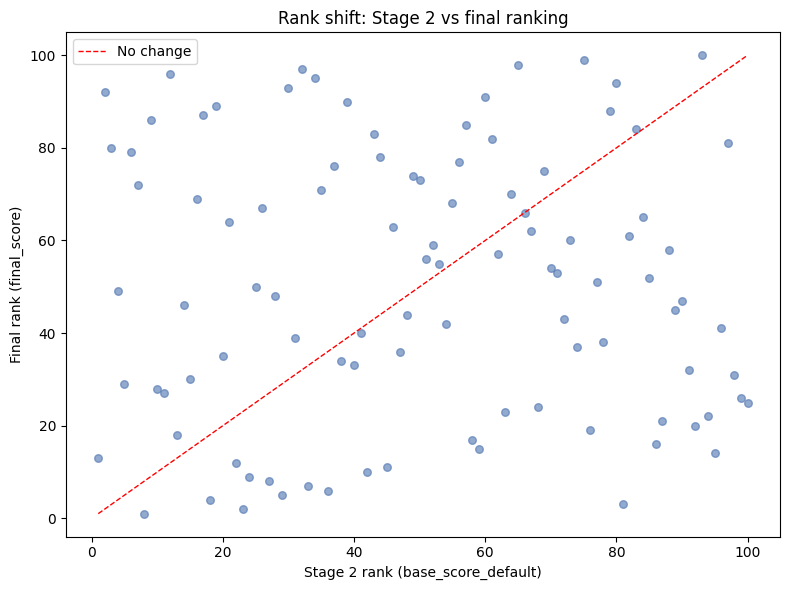

In [ ]:
# Create ranking positions before Stage 3 (structured features only).
# top_k_candidates is already sorted by base_score_default.
stage2_ranks = top_k_candidates[["id"]].reset_index(drop=True)
stage2_ranks["stage2_rank"] = stage2_ranks.index + 1

# Create ranking positions after incorporating the SBERT authenticity score.
stage3_ranks = final_ranking[["id"]].reset_index(drop=True)
stage3_ranks["stage3_rank"] = stage3_ranks.index + 1

# Match each listing's Stage 2 and Stage 3 ranks and compute the change.
# Positive values indicate promotion in the ranking, negative values indicate demotion.
rank_comparison = stage2_ranks.merge(stage3_ranks, on="id")
rank_comparison["rank_change"] = rank_comparison["stage2_rank"] - rank_comparison["stage3_rank"]

# Merge in attributes for interpretation
rank_comparison = rank_comparison.merge(
    final_ranking[["id","neighbourhood_cleansed","host_is_superhost",
                   "calculated_host_listings_count","review_scores_rating",
                   "base_score_default","authenticity_score","final_score"]],
    on="id", how="left"
)

# Visualise ranking stability.
# Listings on the diagonal retained the same rank.
# Points below the diagonal moved up after Stage 3, while points above the diagonal moved down.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rank_comparison["stage2_rank"], rank_comparison["stage3_rank"],
           alpha=0.6, color="#4C72B0", s=30)
ax.plot([1, 100], [1, 100], color="red", linewidth=1, linestyle="--", label="No change")
ax.set_xlabel("Stage 2 rank (base_score_default)")
ax.set_ylabel("Final rank (final_score)")
ax.set_title("Rank shift: Stage 2 vs final ranking")
ax.legend()
plt.tight_layout()
plt.show()

The rank shift chart shows how each of the 100 candidates moves between its Stage 2
position (base quality score only) and its final position (base + authenticity). Most
listings move modestly. The largest upward movers are listings with high authenticity
scores relative to their base quality rank — individually-hosted properties whose review
language strongly matches the authenticity prototype. The largest downward movers are
listings with strong quality signals but low authenticity scores, typically commercial
operators whose reviews use generic rather than neighbourhood-specific language.


In [ ]:
# Top risers and fallers
show_cols = ["id","neighbourhood_cleansed","calculated_host_listings_count",
             "review_scores_rating","base_score_default","authenticity_score",
             "final_score","stage2_rank","stage3_rank","rank_change"]

top_risers  = rank_comparison.nlargest(5, "rank_change")[show_cols].reset_index(drop=True)
top_fallers = rank_comparison.nsmallest(5, "rank_change")[show_cols].reset_index(drop=True)


print("Top 5 risers: listings promoted most by Stage 3 (high authenticity score)")
display(top_risers)
print("\nTop 5 fallers: listings most deprioritised by Stage 3 (lower authenticity score)")
display(top_fallers)

Top 5 risers: listings promoted most by Stage 3 (high authenticity score)


,id,neighbourhood_cleansed,calculated_host_listings_count,review_scores_rating,base_score_default,authenticity_score,final_score,stage2_rank,stage3_rank,rank_change
0,1235805,la Vila de Gràcia,1,4.67,0.809756,0.867385,0.827044,95,14,81
1,1738660,la Vila de Gràcia,1,4.89,0.816103,1.000000,0.871272,81,3,78
2,3501634,la Vila de Gràcia,1,4.94,0.808533,0.777429,0.799202,100,25,75
3,472062,la Vila de Gràcia,4,4.90,0.808660,0.762547,0.794826,99,26,73
4,14164414,les Corts,1,4.92,0.811255,0.798411,0.807402,92,20,72



Top 5 fallers: listings most deprioritised by Stage 3 (lower authenticity score)


,id,neighbourhood_cleansed,calculated_host_listings_count,review_scores_rating,base_score_default,authenticity_score,final_score,stage2_rank,stage3_rank,rank_change
0,1110775765657684157,el Putxet i el Farró,3,4.90,0.885473,0.223182,0.686786,2,92,-90
1,1126613779447054663,el Putxet i el Farró,3,4.86,0.861314,0.256272,0.679801,12,96,-84
2,34191394,la Vila de Gràcia,4,4.74,0.880965,0.294148,0.704920,3,80,-77
3,20066721,la Vila de Gràcia,3,4.95,0.871772,0.293155,0.698187,9,86,-77
4,1025981229888939036,el Putxet i el Farró,3,4.91,0.877614,0.311591,0.707807,6,79,-73


### 6.1.4 Top-5 and bottom-5 final ranking — qualitative review

The cells below show up to 3 English or Spanish reviews for the top-5 and bottom-5
listings in the final ranking. This provides a qualitative complement to the
quantitative comparison above — checking whether the listings the system surfaces
first and last are intuitively coherent with the ranking objective.


In [ ]:
print('TOP-5 FINAL RANKING')
print('=' * 70)
for _, row in final_ranking.head(5).iterrows():
    print(f"\nRank {int(row['final_rank'])} | ID {row['id']} | "
          f"{row['neighbourhood_cleansed']} | "
          f"Host listings: {int(row['calculated_host_listings_count'])} | "
          f"Final score: {row['final_score']:.3f}")
    revs = english_or_spanish_reviews(row['id'], reviews)
    if revs:
        for j, r in enumerate(revs, 1):
            print(f'  Review {j}: {r[:300]}' + ('…' if len(r) > 300 else ''))
    else:
        print('  No qualifying reviews.')

print('\n')
print('BOTTOM-5 FINAL RANKING')
print('=' * 70)
for _, row in final_ranking.tail(5).iterrows():
    print(f"\nRank {int(row['final_rank'])} | ID {row['id']} | "
          f"{row['neighbourhood_cleansed']} | "
          f"Host listings: {int(row['calculated_host_listings_count'])} | "
          f"Final score: {row['final_score']:.3f}")
    revs = english_or_spanish_reviews(row['id'], reviews)
    if revs:
        for j, r in enumerate(revs, 1):
            print(f'  Review {j}: {r[:300]}' + ('…' if len(r) > 300 else ''))
    else:
        print('  No qualifying reviews.')


TOP-5 FINAL RANKING

Rank 1 | ID 33816957 | la Vila de Gràcia | Host listings: 1 | Final score: 0.887
  Review 1: Excelente lugar. En zona super bonita. Solo tuvimos problema con la ducha que salia o fria o super caliente pero sacando eso. Super recomendable !
  Review 2: Amazing location. Very clean and well equipped apartment, perfect for 2-4 people. Gracia is the perfect location to explore the city. It is filled with the best local cafes, bakeries, restaurants, art studios and clothing stores. The apartment is located in the centre of Gracia, close to the neighbo…
  Review 3: I will not recommend this place to anyone.<br/>Shower was broken and replaced only until next day we weren't able to take a shower for 24 hours after traveling by road 6 hours. <br/>They have a 24 hours service for emergencies... It doesn't work for anything and they don't listen or fix your problem…

Rank 2 | ID 357576 | la Vila de Gràcia | Host listings: 1 | Final score: 0.875
<br/>The house is equipped with

### 6.1.3 District distribution across ranking tiers


The table below shows how geographic distribution shifts across three stages
of the pipeline: all 18,177 listings, the Top-100 selected by base ranking
(Stage 2), and the Top-10 by final ranking (Stage 3). This funnel view reveals
whether certain districts are overrepresented at each stage relative to their
share of the full listing pool — a question that connects directly to the bias
analysis in Section 6.3.

Note that Stage 3 cannot change which districts appear in the Top-100 — it only
re-ranks the same 100 listings. Geographic redistribution from authenticity
re-ranking is therefore only visible at the Top-10 level, where reordering
changes which listings surface first.


In [ ]:
# Three-column funnel: All listings → Top-100 → Top-10 final
# Shows how geographic distribution shifts at each stage of the pipeline.
all_districts = (
    listings_mdf["neighbourhood_group_cleansed"]
    .value_counts()
    .rename("All listings (18,177)")
)
top100_districts = (
    top_k_candidates["neighbourhood_group_cleansed"]
    .value_counts()
    .rename("Top-100")
)
top10_final_districts = (
    final_ranking.head(10)["neighbourhood_group_cleansed"]
    .value_counts()
    .rename("Top-10 final")
)

district_funnel = pd.concat(
    [all_districts, top100_districts, top10_final_districts], axis=1
).fillna(0).astype(int)

district_funnel["Top-100 %"] = (
    district_funnel["Top-100"] / district_funnel["Top-100"].sum() * 100
).round(1)
district_funnel["Top-10 %"] = (
    district_funnel["Top-10 final"] / district_funnel["Top-10 final"].sum() * 100
).round(1)

print("District distribution across ranking tiers (% columns sum to 100):")
display(district_funnel.sort_values("Top-100", ascending=False))


District distribution across ranking tiers (% columns sum to 100):


,"All listings (18,177)",Top-100,Top-10 final,Top-100 %,Top-10 %
neighbourhood_group_cleansed,,,,,
Gràcia,1548,81,10,81.0,100.0
Sarrià-Sant Gervasi,1117,10,0,10.0,0.0
Les Corts,405,4,0,4.0,0.0
Sants-Montjuïc,1766,3,0,3.0,0.0
Horta-Guinardó,460,1,0,1.0,0.0
Sant Andreu,278,1,0,1.0,0.0
Eixample,6659,0,0,0.0,0.0
Ciutat Vella,4120,0,0,0.0,0.0
Sant Martí,1634,0,0,0.0,0.0


## 6.2 Validation


### 6.2.1 Base ranking (stage 2) validation

`host_is_superhost` is Airbnb's own quality designation, awarded to hosts who meet thresholds on response rate, cancellation rate, and review scores. It partially overlaps with the inputs to `host_quality_subscore`, so it is not a fully independent signal. The comparison is used as a sanity check: 
- A substantially higher superhost rate in the Top-100 than in the full pool confirms the base score is selecting toward quality rather than against it. 
- If the Top-100 had a lower superhost rate than the full pool, that would indicate the scoring was penalising quality, which would require further explanation.

In [ ]:
top100_ids = set(top_k_candidates["id"])
top100_mask = listings_mdf["id"].isin(top100_ids)

superhost_col = "host_is_superhost"
top100_superhost_rate  = listings_mdf.loc[top100_mask, superhost_col].mean()
overall_superhost_rate = listings_mdf[superhost_col].mean()

print("Superhost prevalence:")
print(f"  Top-100 candidates: {top100_superhost_rate*100:.1f}%")
print(f"  All listings:       {overall_superhost_rate*100:.1f}%")
print(f"  Ratio:              {top100_superhost_rate/overall_superhost_rate:.2f}x")

Superhost prevalence:
  Top-100 candidates: 99.0%
  All listings:       23.0%
  Ratio:              4.31x


On top of that, if the base score discriminates correctly, listings in the Top-100 should also show
systematically better values on every individual input feature, not just on the
composite score itself.

In [ ]:
comparison_cols = [
    "host_response_rate", "host_acceptance_rate", "host_is_superhost",
    "review_scores_rating", "number_of_reviews_ltm",
    "context_subscore",
]

top100_stats  = listings_mdf.loc[top100_mask, comparison_cols].mean()
overall_stats = listings_mdf[comparison_cols].mean()

validation_df = pd.DataFrame({
    "top_100_mean": top100_stats,
    "all_listings_mean": overall_stats,
    "ratio": (top100_stats / overall_stats).round(2),
}).round(3)
validation_df


,top_100_mean,all_listings_mean,ratio
host_response_rate,0.994,0.928,1.07
host_acceptance_rate,0.984,0.853,1.15
host_is_superhost,0.990,0.230,4.31
review_scores_rating,4.847,4.631,1.05
number_of_reviews_ltm,71.630,11.201,6.40
context_subscore,0.752,0.431,1.74


The ratio consistently above 1.0 across all input features confirms the base score
discriminates in the intended direction. A superhost prevalence ratio of 4x in
the Top-100 versus the full pool is meaningful external validation, since superhost
status is computed by Airbnb independently of every feature used in this scoring
pipeline.

#### Sensitivity Analysis (Stage 2)

Stage 2 (base ranking) weights were chosen rather than learned, so it is worth checking how much the
result depends on the exact values used. 
- If slightly different weights produced nearly the same Top-100, the ranking would not be sensitive to the specific weight choice. 
- If the lists changed substantially, weight choice would matter more. 

Three configurations are compared (the default weights, one favouring review quality, one favouring context)
using Jaccard similarity: the proportion of listings shared between two Top-100 lists,
out of all listings appearing in either.

In [ ]:
# Sensitivity analysis runs on the filtered pool for consistency with the pipeline.
K = TOP_K
topk_sets = {
    name: set(listings_filtered.nlargest(K, f"base_score_{name}")["id"])
    for name in WEIGHT_CONFIGS
}

print(f"Top-{K} overlap across weight configurations (Jaccard similarity):")
names = list(WEIGHT_CONFIGS.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = topk_sets[names[i]], topk_sets[names[j]]
        jaccard = len(a & b) / len(a | b)
        print(f"  {names[i]:15s} vs {names[j]:15s}: "
              f"{len(a & b):3d}/{K} common, Jaccard = {jaccard:.3f}")


Top-100 overlap across weight configurations (Jaccard similarity):
  default         vs review_heavy   :  91/100 common, Jaccard = 0.835
  default         vs context_heavy  :  81/100 common, Jaccard = 0.681
  review_heavy    vs context_heavy  :  74/100 common, Jaccard = 0.587


The sensitivity analysis compares three weight configurations using Jaccard similarity:
the proportion of listings shared between two Top-K lists out of all listings appearing
in either. A Jaccard value near 1.0 would mean weight choice has almost no effect on
the candidate set. A value near 0 would mean the configurations select almost entirely
different listings, which would require much stronger justification for the chosen
weights.

- The default and review-heavy configurations share 91 listings, reflecting that
high-quality listings tend to score well on both host and review dimensions
simultaneously — shifting weight between them does not substantially change
who makes the Top-100. The Jaccard of 0.835 is high, confirming the ranking
is robust to this weight change.

- The default vs context-heavy comparison shows more movement (Jaccard 0.681,
19 listings replaced). Context — transport and POI proximity — is different: listings that 
score well on host and review quality are not necessarily in the most accessible or culturally dense areas. Giving context a larger weight meaningfully reshapes the candidate set.

- The review-heavy vs context-heavy comparison has the lowest overlap
(Jaccard 0.587, 26 listings differ), confirming these two configurations
represent the most distinct priorities in the model. 

Together, the results show a moderate range of Jaccard values (0.587–0.835): the ranking is
sensitive to weight choice in some dimensions but not unstable overall,
which supports the use of the default weights without requiring them to be
uniquely correct.

### 6.2.2 Authenticity re-ranking (Stage 3) validation

Stage 3 has no equivalent independent ground truth, so two complementary checks are
used: 
- a direct reading of the highest and lowest scoring listings' reviews, 
- and a correlation between two signals that measure authenticity through entirely independent
means.

**Reading the highest and lowest scoring listings.** For each of the 5 highest and 5
lowest `authenticity_score` listings, up to 3 complete individual reviews are shown
(filtered to English and Spanish, since those are the languages that can be verified
directly). This is a qualitative check: if the high-scoring listings plausibly read as
more locally embedded than the low-scoring ones, that supports the SBERT signal
capturing something real rather than noise.

In [ ]:
# Select the listings with the highest and lowest authenticity scores.
top5_auth    = final_ranking.nlargest(5, "authenticity_score")[["id", "authenticity_score"]]
bottom5_auth = final_ranking.nsmallest(5, "authenticity_score")[["id", "authenticity_score"]]

# Display representative reviews for the highest-scoring listings.
# They should contain language associated with authentic local experiences.
print("Highest-scoring listings (authenticity_score):")
for _, row in top5_auth.iterrows():
    listing_id = row["id"]
    score = row["authenticity_score"]
    print(f"\n--- ID {listing_id} (score = {score:.3f}) ---")
    excerpts = english_or_spanish_reviews(listing_id, reviews)
    if not excerpts:
        print("  (no qualifying English/Spanish reviews found)")
    for j, text in enumerate(excerpts, 1):
        print(f"  Review {j}: {text}")

# Display representative reviews for the lowest-scoring listings.
# These provide a contrast with the highly authentic examples and
# help verify that the score aligns with qualitative judgement.
print("\n" + "="*70)
print("Lowest-scoring listings (authenticity_score):")
for _, row in bottom5_auth.iterrows():
    listing_id = row["id"]
    score = row["authenticity_score"]
    print(f"\n--- ID {listing_id} (score = {score:.3f}) ---")
    excerpts = english_or_spanish_reviews(listing_id, reviews)
    if not excerpts:
        print("  (no qualifying English/Spanish reviews found)")
    for j, text in enumerate(excerpts, 1):
        print(f"  Review {j}: {text}")
    


Highest-scoring listings (authenticity_score):

--- ID 1738660.0 (score = 1.000) ---
<br/>We couldn´t have chosen a better place to stay!!!!g is brand new, clean, and all details have been taken in care. Since its a third floor, it is very luminous and has wonderful views from the balcony to the plaza.ing easy and comfortable.
  Review 2: Great host. Great flat. The brand new terrace is really amazing.... Huge and well orientated. We really slept like babies. The bedroom was dark enough and the bed comfortable. <br/>Everything was really nice, from our arrival to our leaving, on which lluis was really flexible. <br/>In two words: highly recommended ! 
  Review 3: Lluis is a perfect host: warm welcome, he makes himself available even if I arrived late in the evening. Lluis left me some very fresh fruits: I lived that!!! The apartment is also outstanding: it is located on a very nice and lively placa near restaurants and lovely shops. Nevertheless the apartment is very calm. The area is 

Known limitation: `auth_host_scale` penalises hosts with multiple listings but cannot detect single-listing hosts operating at commercial scale through high guest turnover. A host with one listing and over 1,000 reviews is likely running a near-professional operation despite appearing as an
individual host structurally. `calculated_host_listings_count` is the only host-scale signal available in this dataset and does not capture this distinction. Listings that score high on the structural subscore but have unusually high review counts should be interpreted with caution.


**Cross-signal correlation.** `sbert_text_score` is derived entirely from review
language. `auth_host_scale` is derived entirely from host account structure (listing
count), with no text involved. If these independently-derived signals correlate, that
supports the idea that both are capturing a shared underlying concept of authenticity
rather than each being noise pointing in different directions.

In [ ]:
text_vs_scale_r, text_vs_scale_p = pearsonr(
    final_ranking["sbert_text_score"], final_ranking["auth_host_scale_norm"]
)
print(f"SBERT text score vs auth_host_scale: r = {text_vs_scale_r:.3f}, p = {text_vs_scale_p:.4f}")

SBERT text score vs auth_host_scale: r = 0.056, p = 0.5807


A positive correlation between the language-based and host-structure-based signals supports the construct validity of `authenticity_score` as a whole. However, it is a near-zero correlation. This does not necessarily invalidate the model, since the two signals are intentionally independent, but it does weaken the claim that they jointly measure the same underlying concept.

## 6.3 Evaluation against objectives

This section evaluates whether the system meets the objectives set in Phase 1.
Two questions are addressed:

1. **Bias audit**: does the ranking inadvertently correlate with neighbourhood
   socioeconomic status — specifically, does it favour listings in wealthier areas?
2. **Business objectives**: does the system surface the kind of listings it was
   designed to surface — individually-hosted, locally-embedded properties?


### 6.3.1 Bias audit: neighbourhood income

Neighbourhood income (Idescat 2022) is aggregated from
census-section level to neighbourhood level and joined to the ranking outputs.
The bias check runs at neighbourhood granularity (the finest level available
in this dataset), so it captures whether the system tends to rank listings
in wealthier or poorer neighbourhoods more highly (not whether it favours
wealthier hosts or guests directly)

**Caveat on data granularity**: a luxury property and an affordable local flat
in the same neighbourhood are treated identically by this analysis. This is a
limitation of the available data rather than a methodological choice, and means
the bias audit is a necessary but not sufficient check for socioeconomic fairness.


In [ ]:
# Strip AEI district suffixes present in two Nom_Barri entries
# ('el Poble Sec - AEI Parc Montjuic', 'la Marina del Prat Vermell - AEI Zona Franca')
# so they align with the neighbourhood_cleansed names in listings.
income_clean = income.copy()
income_clean["Nom_Barri"] = income_clean["Nom_Barri"].str.split(" - AEI").str[0]

income_by_neighbourhood = (
    income_clean.groupby("Nom_Barri")["Import_Euros"]
    .mean()
    .reset_index()
    .rename(columns={"Nom_Barri": "neighbourhood_cleansed",
                     "Import_Euros": "neighbourhood_income"})
)
print(f"Neighbourhoods with income data: {len(income_by_neighbourhood)}")
print(income_by_neighbourhood.describe().round(0))


Neighbourhoods with income data: 73
       neighbourhood_income
count                  73.0
mean                21945.0
std                  6207.0
min                 11796.0
25%                 18088.0
50%                 21025.0
75%                 24766.0
max                 41344.0


The analysis runs on both ranking stages to show whether authenticity re-ranking corrects, preserves, or introduces income bias relative to the base ranking.

In [ ]:
top_k_with_income = top_k_candidates.merge(
    income_by_neighbourhood, on="neighbourhood_cleansed", how="left"
)
final_with_income = final_ranking.merge(
    income_by_neighbourhood, on="neighbourhood_cleansed", how="left"
)

base_r, base_p = pearsonr(
    top_k_with_income["neighbourhood_income"],
    top_k_with_income["base_score_default"]
)
print(f"Base ranking (Top-100) vs income:  Pearson r = {base_r:.3f}, p = {base_p:.4f}")

final_r, final_p = pearsonr(
    final_with_income["neighbourhood_income"],
    final_with_income["final_score"]
)
print(f"Final ranking vs income:           Pearson r = {final_r:.3f}, p = {final_p:.4f}")


Base ranking (Top-100) vs income:  Pearson r = 0.055, p = 0.5867
Final ranking vs income:           Pearson r = -0.242, p = 0.0153


The base ranking is income-neutral (r = 0.055, p = 0.587): Stage 2 quality signals do not systematically favour listings in wealthier neighbourhoods. The final ranking shows a mild but statistically significant tendency to favour lower-to-middle income neighbourhoods (r = −0.242, p = 0.015). This is
consistent with the geographic concentration of top authenticity scores in Gràcia, a historically working-class neighbourhood that has gentrified moderately but remains less affluent than the highest-income districts (e.g. les Tres Torres, Sarrià). The system does not raise concerns aboutsocioeconomic bias in the direction that would be most problematic (systematically favouring luxury  areas).


The table below shows mean neighbourhood income by ranking tier — full pool,
Top-100, and Top-10 — providing a complementary view of the bias audit results
presented above.


In [ ]:
all_with_income = listings_mdf.merge(
    income_by_neighbourhood, on="neighbourhood_cleansed", how="left"
)

# Top-10 by base score (Stage 2 quality ranking)
top10_base_ids    = set(top_k_candidates.nlargest(10, "base_score_default")["id"])
top10_base_income = all_with_income[
    all_with_income["id"].isin(top10_base_ids)
]["neighbourhood_income"]

# Top-10 by final score (Stage 2 + Stage 3 authenticity ranking)
top10_final_ids    = set(final_ranking.head(10)["id"])
top10_final_income = all_with_income[
    all_with_income["id"].isin(top10_final_ids)
]["neighbourhood_income"]

overall_mean     = all_with_income["neighbourhood_income"].mean()
top10_base_mean  = top10_base_income.mean()
top10_final_mean = top10_final_income.mean()

print(f"Mean neighbourhood income:")
print(f"  Full pool (n={len(all_with_income):,}):       {overall_mean:,.0f} EUR")
print(f"  Top-10 by base score:    {top10_base_mean:,.0f} EUR  "
      f"({(top10_base_mean/overall_mean - 1)*100:+.1f}% vs full pool)")
print(f"  Top-10 by final score:   {top10_final_mean:,.0f} EUR  "
      f"({(top10_final_mean/overall_mean - 1)*100:+.1f}% vs full pool)")
print(f"  Stage 3 shift:           {top10_final_mean - top10_base_mean:+,.0f} EUR  "
      f"({(top10_final_mean/top10_base_mean - 1)*100:+.1f}% vs Stage 2 Top-10)")


Mean neighbourhood income:
  Full pool (n=18,177):       23,785 EUR
  Top-10 by base score:    25,705 EUR  (+8.1% vs full pool)
  Top-10 by final score:   24,863 EUR  (+4.5% vs full pool)
  Stage 3 shift:           -843 EUR  (-3.3% vs Stage 2 Top-10)


### 6.3.2 User evaluation: blind retrieval test

To validate the final ranking beyond internal consistency checks, a blind
retrieval evaluation is conducted following the protocol proposed by the
project supervisor.

**Protocol:**
1. Take the **Top-4 listings by `final_score`** from the final ranking
2. Sample **4 listings at random** from `listings_filtered` (the trip-eligible
   pool), excluding any that appear in the Top-100
3. Shuffle the 8 listings together and remove all scores
4. Present to evaluators with: listing name, neighbourhood, host listing count,
   superhost status, and up to 3 review excerpts
5. Ask: *'Which 4 of these 8 listings would you most want to stay in for an
   authentic Barcelona experience — high quality AND feeling genuinely local,
   run by someone who actually lives there and is personally invested in your
   experience?'*

**Scoring:** each evaluator selects 4 from 8. Expected score by random chance:
2.0/4. A mean score of 3–4 across evaluators indicates the model is surfacing
recognisably authentic listings. Probability of selecting all 4 correctly by
chance: 1/C(8,4) = 1/70 ≈ 1.4%.

The cell below generates the shuffled evaluation set and exports it to a
formatted document (`evaluation_set.json`) for use in the evaluation form.


In [ ]:
# EVAL_SEED ensures reproducibility — same seed produces identical sets across runs.
EVAL_SEED = RANDOM_SEED

def _host_category(n):
    if n <= 2:   return "Individual host (1–2 listings)"
    if n <= 10:  return "Small operator (3–10 listings)"
    return "Commercial operator (10+ listings)"

def _clean_review(text):
    """Strip HTML tags only — full review text shown to evaluators."""
    if not text:
        return ""
    text = re.sub(r'<br\s*/?>', ' ', text, flags=re.IGNORECASE)
    return re.sub(r'<[^>]+>', '', text).strip()

# Top-4 from final ranking (rank-based, no handpicking)
top4_rows = final_ranking.head(4).copy()

# 4 random listings from the eligible pool, excluding Top-100
top100_ids = set(top_k_candidates['id'])
eligible_non_top100 = listings_filtered[~listings_filtered['id'].isin(top100_ids)].copy()
random4_rows = eligible_non_top100.sample(4, random_state=EVAL_SEED)

# Build evaluation records
eval_records = []
for _, row in top4_rows.iterrows():
    lid = row['id']
    _revs = listing_review_lists.get(lid, [])
    eval_records.append({
        'source': 'model_top4',
        'id': int(lid),
        'name': str(row.get('name', '') or ''),
        'neighbourhood': row['neighbourhood_cleansed'],
        'host_listings': int(row['calculated_host_listings_count']),
        'superhost': bool(row['host_is_superhost']),
        'rating': round(float(row['review_scores_rating']), 2),
        'reviews': [_clean_review(r) for r in _revs[:3]],
        'host_category': _host_category(int(row['calculated_host_listings_count'])),
    })
for _, row in random4_rows.iterrows():
    lid = row['id']
    _revs = listing_review_lists.get(lid, [])
    eval_records.append({
        'source': 'random',
        'id': int(lid),
        'name': str(row.get('name', '') or ''),
        'neighbourhood': row['neighbourhood_cleansed'],
        'host_listings': int(row['calculated_host_listings_count']),
        'superhost': bool(row['host_is_superhost']),
        'rating': round(float(row['review_scores_rating']), 2) if pd.notna(row['review_scores_rating']) else None,
        'reviews': [_clean_review(r) for r in _revs[:3]],
        'host_category': _host_category(int(row['calculated_host_listings_count'])),
    })

# Shuffle — evaluators see no ordering cue
random.seed(EVAL_SEED)
random.shuffle(eval_records)

# Assign display labels A–H
letters = list('ABCDEFGH')
for rec, letter in zip(eval_records, letters):
    rec['label'] = letter

# Save full set (with source) for scoring
eval_path = DATA_DIR / 'evaluation_set.json'
with open(eval_path, 'w', encoding='utf-8') as f:
    json.dump(eval_records, f, ensure_ascii=False, indent=2)
print(f'Evaluation set saved to {eval_path}')
print(f'Model Top-4 labels: {[r["label"] for r in eval_records if r["source"]=="model_top4"]}')
print('(Keep this hidden from evaluators until after the evaluation is complete)\n')

# Print evaluator-facing view (no source column)
print('=== EVALUATOR VIEW (no scores, no source) ===')
for rec in eval_records:
    sup = 'Superhost' if rec['superhost'] else 'Not superhost'
    print(f"\n{'='*60}")
    print(f"Listing {rec['label']}: {rec['name'][:60]}")
    print(f"  Neighbourhood : {rec['neighbourhood']}")
    print(f"  Host listings : {rec['host_listings']} | {sup} | Rating: {rec['rating']}")
    for j, rev in enumerate(rec['reviews'], 1):
        print(f"  Review {j}: {rev[:400]}" + ("…" if len(rev) > 400 else ""))
    print(f"  Host type     : {rec['host_category']}")


Evaluation set saved to /Users/anabechara/Desktop/Master/TFM/data/evaluation_set.json
Model Top-4 labels: ['A', 'E', 'G', 'H']
(Keep this hidden from evaluators until after the evaluation is complete)

=== EVALUATOR VIEW (no scores, no source) ===

Listing A: 
  Neighbourhood : la Vila de Gràcia
  Host listings : 1 | Superhost | Rating: 4.78
  Review 1: Myself and my partner visited Ana's property at the end of April. This is our honest review of our stay at this apartment.  The location was fantastic. You're in the area of Vila De Gracia. This entire area, including the Fontana Metro and surrounding areas, are beautiful delights full of amazing little family/independent businesses, cafes, restaurants, shops and Pizzeria's. There is so much to do…
  Review 2: I stayed here for 3 weeks and had a great time. The apartment worked well, but I definitely felt slightly mislead reading the prior reviews.  I was expecting to walk into a clean and comfortable apartment.  Upon arrival it seemed 

In [ ]:
# Scoring: enter each evaluator's selections as a list of letters
# Example: evaluator_responses = [['A','C','E','G','I'], ['B','C','F','G','J']]

evaluator_responses = [
    ['A', 'C', 'D', 'H'],  # evaluator 1 
    ['A', 'C', 'D', 'H'],  # evaluator 2 
    ['A', 'C', 'D', 'H'],  # evaluator 3
]

if evaluator_responses:
    model_labels = set(r['label'] for r in eval_records if r['source'] == 'model_top4')
    print(f'Model Top-5 labels: {sorted(model_labels)}')
    print(f'Expected by chance: 2.0 / 4  (selecting 4 from 8 at random)\n')
    scores = []
    for j, selections in enumerate(evaluator_responses, 1):
        correct = len(set(selections) & model_labels)
        scores.append(correct)
        print(f'Evaluator {j}: selected {selections} → {correct}/4 correct')
    print(f'\nMean correct: {sum(scores)/len(scores):.2f} / 4')
    print(f'Range: {min(scores)} – {max(scores)}')
else:
    print('Fill in evaluator_responses above after collecting responses.')


Model Top-5 labels: ['A', 'E', 'G', 'H']
Expected by chance: 2.0 / 4  (selecting 4 from 8 at random)

Evaluator 1: selected ['A', 'C', 'D', 'H'] → 2/4 correct
Evaluator 2: selected ['A', 'C', 'D', 'H'] → 2/4 correct
Evaluator 3: selected ['A', 'C', 'D', 'H'] → 2/4 correct

Mean correct: 2.00 / 4
Range: 2 – 2


**Evaluation results and interpretation**

All three evaluators selected listings A, C, D, and H. The model's Top-4 were A, E, G, and H.
Score: 2/4 per evaluator (mean 2.0/4), equal to the random chance baseline of 2.0/4.

- **Why G was not selected**: listing G (ID 33816957) contains a strongly negative operational
review describing broken facilities, an unresponsive host, and cleaning staff entering the
apartment unannounced. All three evaluators excluded it on these grounds. This is consistent
with a known limitation of the model: SBERT scores the authenticity of review language, not
the operational quality of the stay. The other two reviews for this listing are rich in
Gràcia-specific local character language, which is why the model scored it highly.

- **Why E was not selected**: listing E (Lluis, Gràcia) has reviews with strong local character
signals — named host, specific square, authentic neighbourhood description. However, evaluators
preferred C and D, which had more immediately compelling personal host interactions. This
suggests the SBERT score and human judgment can diverge on listings where the local signal
is present but less salient than in competing listings.

- **Why C and D were selected**: both are genuinely locally-hosted listings — C (Antonio,
Eixample, 4.96 rating) and D (Albert/Laia, Eixample, personal warm reviews) read as
authentically local to all three evaluators. However, their base scores (0.673 and 0.632)
are well below the Top-100 threshold (0.816), meaning the system correctly excluded them
from Stage 3 on quality grounds. They are authentically local but not high-quality enough
to compete in the candidate pool.

**Protocol limitation**: sampling random listings from outside the Top-100 was not the
optimal design. Because random listings were not quality-matched to the model's Top-4,
the evaluation conflates two questions: whether the system identifies authentic listings,
and whether it identifies high-quality ones. A more controlled design would sample random
listings from within the Top-100 — listings that passed the quality threshold — to isolate
whether the authenticity re-ranking adds discriminating power beyond quality alone.

**What can still be concluded**: A and H were correctly identified by all three evaluators,
confirming that the model's highest authenticity scorers are recognisably locally-hosted to
independent judges. The result is partially informative despite the protocol limitation.
A redesigned evaluation sampling random listings from within the Top-100 would provide
a cleaner test of the Stage 3 contribution in future work.

# Export for Deployment

The two cells below export the data files required by the Streamlit demo app.
Run after all scoring cells in Phase 5 have completed.

- `listings_scored.csv`: all 18,177 listings with base scores and, where
  available, Stage 3 authenticity and final scores.
- `top100_reviews.json`: up to 3 qualifying English/Spanish reviews per
  Top-100 listing, used by the app without loading the full 308 MB file.

In [ ]:
# Export full scored dataset for the deployment app.
# Includes listing name and URL so the app can link to Airbnb directly.

stage3_cols = ["id", "sbert_text_score", "host_authenticity_subscore",
               "authenticity_score", "final_score"]
available = [c for c in stage3_cols if c in top_k_candidates.columns]
missing   = [c for c in stage3_cols if c not in top_k_candidates.columns]
if missing:
    print(f"Warning: {missing} missing from top_k_candidates")

listings_export = listings_mdf.merge(
    top_k_candidates[available], on="id", how="left"
)

# Add listing name and URL from the raw listings dataframe
listings_export = listings_export.merge(
    listings[["id", "name", "listing_url"]], on="id", how="left"
)

export_cols = [
    "id", "name", "listing_url",
    "latitude", "longitude",
    "neighbourhood_cleansed", "neighbourhood_group_cleansed",
    "room_type", "accommodates", "minimum_minimum_nights",
    "host_is_superhost", "review_scores_rating",
    "calculated_host_listings_count", "number_of_reviews_ltm",
    "host_quality_subscore", "review_quality_subscore",
    "context_subscore", "base_score_default",
    "sbert_text_score", "host_authenticity_subscore",
    "authenticity_score", "final_score",
]

for col in export_cols:
    if col not in listings_export.columns:
        listings_export[col] = float("nan")

listings_export[export_cols].to_csv(DATA_DIR / "listings_scored.csv", index=False)
print(f"Exported {len(listings_export):,} listings to listings_scored.csv")
print(f"  With Stage 3 scores: {listings_export['authenticity_score'].notna().sum():,}")
print(f"  Base score only:     {listings_export['authenticity_score'].isna().sum():,}")


Exported 18,177 listings to listings_scored.csv
  With Stage 3 scores: 100
  Base score only:     18,077


In [ ]:
# Export top-3 English/Spanish reviews per Top-100 listing for the app.
# Saves a small JSON (~50-100 KB) so the app can show review excerpts without shipping the full 308 MB reviews.csv.
def get_top3_reviews(listing_id, reviews_df, max_reviews=3, min_words=20):
    """Return up to 3 complete English (EN) / Spanish (ES) reviews for a listing, longest first."""
    candidates = (
        reviews_df[reviews_df["listing_id"] == listing_id]["comments"]
        .dropna()
        .pipe(lambda s: s[s.str.split().str.len() >= min_words])
        .sort_values(key=lambda s: s.str.len(), ascending=False)
    )
    kept = []
    for text in candidates:
        if detect is None:
            kept.append(text)
        else:
            try:
                if detect(text) in ("en", "es"):
                    kept.append(text)
            except LangDetectException:
                continue
        if len(kept) >= max_reviews:
            break
    return kept

top100_reviews = {}
top100_ids = top_k_candidates["id"].tolist()

# Ensure reviews_raw is the original dataframe, not a list from a later cell
reviews_raw = pd.read_csv(DATA_DIR / "reviews.csv")
print(f"Extracting reviews for {len(top100_ids)} listings...")
for lid in top100_ids:
    top100_reviews[int(lid)] = get_top3_reviews(lid, reviews_raw)

reviews_path = DATA_DIR / "top100_reviews.json"
with open(reviews_path, "w", encoding="utf-8") as f:
    json.dump(top100_reviews, f, ensure_ascii=False, indent=2)

n_with_reviews = sum(1 for v in top100_reviews.values() if v)
print(f"Saved reviews for {n_with_reviews}/{len(top100_ids)} listings to {reviews_path}")
print(f"File size: {reviews_path.stat().st_size / 1024:.0f} KB")


Extracting reviews for 100 listings...
Saved reviews for 100/100 listings to /Users/anabechara/Desktop/Master/TFM/data/top100_reviews.json
File size: 390 KB
